# Gas model — BVAR with stochastic volatility and model-based outliers

This notebook estimates the monthly gas-price model using two processed level series.

## Origin and construction of the model series

| Model series | Native or constructed? | Construction before this notebook |
|---|---|---|
| `natural_gas_wholesale` | **Chain-linked backcast** | Bloomberg daily TTF in EUR/MWh; monthly average ; earlier months follow World Bank *Natural gas, Europe* growth and are chain-linked to the TTF level at the junction (backast). |
| `gas_pre_tax` | **Constructed price level** | Haver HICP gas **index**. Rescaled to the Eurostat after-tax household **price**. Eurostat prices and excise are converted from EUR/kWh to EUR/MWh by multiplying by 1,000; VAT and excise are then removed. |

The wholesale backcast is

$$
P_t^{\mathrm{wholesale}}
=
P_{t_0}^{\mathrm{TTF}}
\frac{P_t^{\mathrm{WB}}/FX_t}{P_{t_0}^{\mathrm{WB}}/FX_{t_0}},
\qquad t<t_0.
$$

The consumer pre-tax price is

$$
P_t^{\mathrm{gas,pre\text{-}tax}}
=
\frac{\widehat{\gamma}_{\mathrm{MWh}}P_t^{\mathrm{HICP\ gas}}}
{1+VAT_t/100}
-
EXC_t^{\mathrm{EUR/MWh}}.
$$

{\widehat{\gamma} is the OLS estimated coefficient of : price = {\widehat{\gamma} * HICP_index + epsilon.

The inverse transformation used after forecasting is

$$
P_t^{\mathrm{HICP\ gas}}
=
\frac{
\left(P_t^{\mathrm{gas,pre\text{-}tax}}+EXC_t^{\mathrm{EUR/MWh}}\right)
\left(1+VAT_t/100\right)
}{\widehat{\gamma}_{\mathrm{MWh}}}.
$$

Estimation uses ordinary absolute monthly changes,

$$
\Delta P_t=P_t-P_{t-1},
$$

both endogenous variables are measured in EUR/MWh.

## Model ordering and forecasting workflow

$$
y_t=
\begin{pmatrix}
\Delta P_t^{\mathrm{wholesale\ gas}}\\
\Delta P_t^{\mathrm{consumer\ gas,pre\text{-}tax}}
\end{pmatrix},
\qquad p=12.
$$

The ordering permits a contemporaneous wholesale-to-consumer effect but excludes the reverse contemporaneous effect (i.e., the market drives the consumer price, not the reverse, at the monthly frequency). Parameters are estimated on the maximal balanced block (non n/a values); the Durbin–Koopman smoother then handles the ragged edge and produces nowcasts and short forecasts.

## 1. Imports and configuration

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / "src").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
MODEL_DIR_CANDIDATES = [
    PROJECT_ROOT / "src" / "model",
    PROJECT_ROOT,
    Path.cwd(),
]
for candidate in MODEL_DIR_CANDIDATES:
    if (candidate / "energy_bvar_sv_outlier_model_function_v7.py").exists():
        sys.path.insert(0, str(candidate))
        MODEL_DIR = candidate
        break
else:
    raise FileNotFoundError(
        "Place the two Python modules either beside this notebook or in src/model/."
    )

from energy_bvar_sv_outlier_model_function_v7 import (
    BVARSVOPriorConfig,
    SamplerConfig,
    coefficient_posterior_tables,
    forecast_bvar_sv_outlier,
    forecast_horizon_table,
    forecast_to_hicp_gas,
    gas_fevd,
    gas_historical_decomposition,
    gas_impulse_responses,
    gas_series_construction_table,
    gibbs_bvar_sv_outlier,
    load_gas_panel,
    load_gas_tax_context,
    make_bvar_svo_prior,
    mcmc_diagnostics,
    nowcast_summary_table,
    path_horizon_table,
    posterior_outlier_probability,
    posterior_predictive_statistics,
    prepare_bvar_panel,
    residual_diagnostic_table,
    stability_diagnostics,
    stationarity_tests,
    validate_tax_round_trip,
)
from energy_bvar_sv_outlier_plot_function_v9 import (
    plot_absolute_differences,
    plot_chain_acf_grid,
    plot_coefficient_heatmap,
    plot_data_levels,
    plot_forecast_comparison,
    plot_gas_fevd,
    plot_gas_historical_decomposition,
    plot_gas_irf,
    plot_hicp_forecast_fan,
    plot_minnesota_prior_by_equation,
    plot_nowcast_fan,
    plot_phi_and_outlier_priors,
    plot_posterior_predictive_check,
    plot_volatility_decomposition,
    plot_short_forecast_fan,
    plot_shrinkage_comparison,
    plot_spectral_radius,
    plot_standardized_residuals,
    plot_trace_grid,
    format_number,
    style_numeric_table,
)

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

SEED = 42
P = 12
VARIABLES = ["natural_gas_wholesale", "gas_pre_tax"]
print(f"Project root: {PROJECT_ROOT}")
print(f"Model modules: {MODEL_DIR}")

Project root: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy
Model modules: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\src\model


In [2]:
# Select the latest processed vintage by default.
# Set VINTAGE = "YYYYMMDD" to force a specific vintage.
VINTAGE = None
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed"

if VINTAGE is None:
    candidates = sorted(
        path for path in PROCESSED_ROOT.glob("*/gas_monthly.csv")
        if path.is_file()
    )
    if not candidates:
        raise FileNotFoundError(
            f"No gas_monthly.csv found below {PROCESSED_ROOT}."
        )
    GAS_DATASET = candidates[-1]
else:
    GAS_DATASET = PROCESSED_ROOT / VINTAGE / "gas_monthly.csv"

levels = load_gas_panel(GAS_DATASET, variables=VARIABLES)
print(f"Dataset: {GAS_DATASET}")
print(f"Sample calendar: {levels.index.min().date()} to {levels.index.max().date()}")

display(style_numeric_table(
    gas_series_construction_table(GAS_DATASET),
    caption="Construction of the two model series",
))
display(style_numeric_table(
    levels.tail(12),
    caption="Latest processed levels (EUR/MWh)",
))

Dataset: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\data\processed\20260805\gas_monthly.csv
Sample calendar: 2003-07-01 to 2026-08-01


,series_type,model_unit,source_inputs,level_construction,important_note,notebook_transformation
model series,,,,,,
natural_gas_wholesale,chain-linked backcast,EUR/MWh,"Bloomberg TTF; World Bank Natural gas, Europe; EUR/USD","Bloomberg TTF monthly mean; earlier months backcast with the World Bank Natural gas, Europe proxy via backward chain-linking. The proxy level is pinned to TTF at the anchor month; no overlap window and no level regression are estimated.","The paper uses Energy Intelligence European border gas. World Bank Natural gas, Europe is the public substitute and belongs to the same European border/import-price family. TTF anchor month: 2011-02-01.",ordinary absolute first difference: P_t - P_{t-1}
gas_pre_tax,constructed pre-tax price,EUR/MWh,"Haver HICP gas; Eurostat after-tax price, VAT and excise",pre_tax_EUR_MWh = gamma_EUR_MWh * HICP / (1 + VAT/100) - EXC_EUR_MWh,"After the final published six-month semester, VAT and excise are held constant through the last available monthly HICP observation, matching the paper's unchanged-tax assumption. Estimated gamma: 1.20067.",ordinary absolute first difference: P_t - P_{t-1}


,natural_gas_wholesale,gas_pre_tax
date,,
2025-09-01,32.02,78.68
2025-10-01,32.04,77.54
2025-11-01,30.66,77.37
2025-12-01,27.42,77.61
2026-01-01,34.52,77.00
2026-02-01,32.51,77.52
2026-03-01,52.63,79.56
2026-04-01,45.26,83.03
2026-05-01,47.34,84.62


## 2. Data and transformations

,first_valid,last_valid,observations,missing,minimum,maximum,mean,standard_deviation
natural_gas_wholesale,2003-07-01,2026-08-01,278.00,0.00,4.54,234.54,27.96,25.80
gas_pre_tax,2003-07-01,2026-06-01,276.00,2.00,37.46,134.69,57.84,17.50


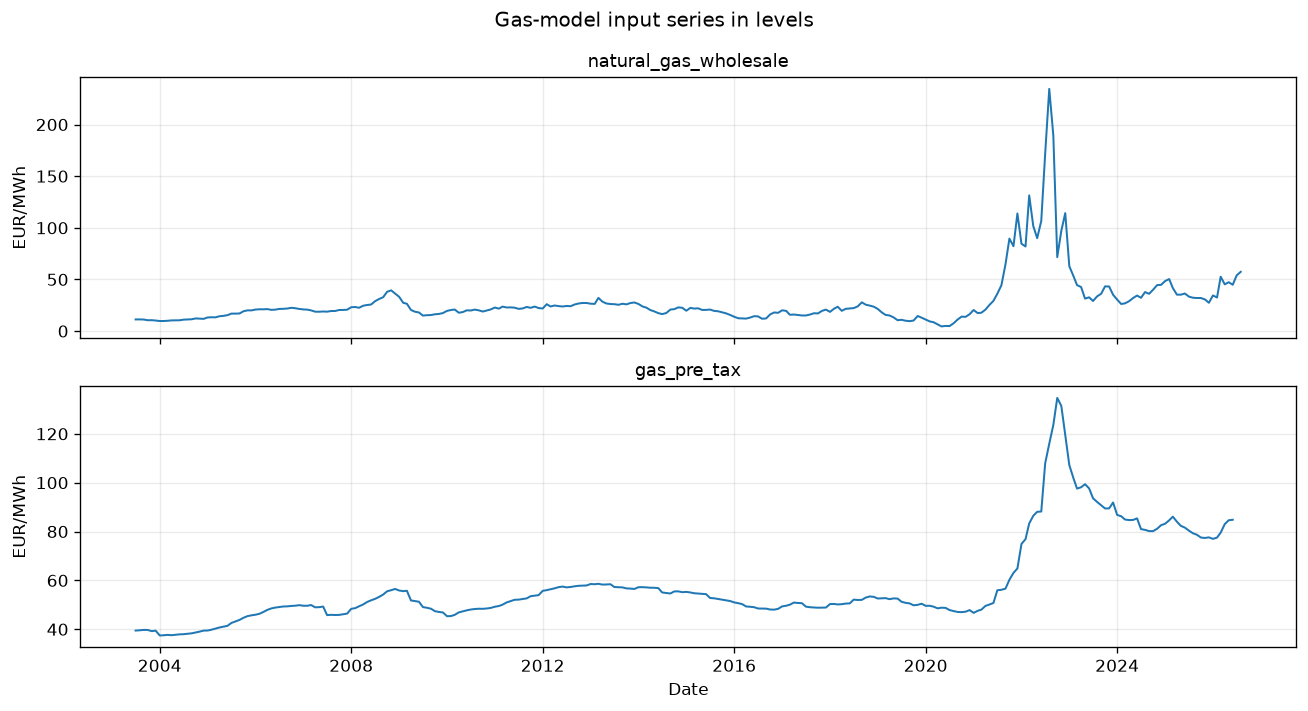

In [3]:
data_summary = pd.DataFrame({
    "first_valid": levels.apply(lambda s: s.first_valid_index()),
    "last_valid": levels.apply(lambda s: s.last_valid_index()),
    "observations": levels.notna().sum(),
    "missing": levels.isna().sum(),
    "minimum": levels.min(),
    "maximum": levels.max(),
    "mean": levels.mean(),
    "standard_deviation": levels.std(),
})
display(style_numeric_table(data_summary, caption="Input-series summary — levels in EUR/MWh"))
plot_data_levels(levels)
plt.show()

good point: both series' shape look similar. We accurately have a supposed relation between the upstream (supplier and trader, exclude taxes and distribution) Title Transfer Facility (TTF) natural gas (by opposition to gasoline/petrol and LPG (propane)) price and the downstream (household, pre taxe and accises but transportation and supplier margin include) one (mainly natural gas but broader basket in some countries). 
The wholesale is an average of daily market price, that is why its volatility is higher, shape more euristic and more "noisy" by nature.

### Absolute monthly changes

The BVAR is estimated on ordinary absolute changes:

$$
\Delta P_t=P_t-P_{t-1}.
$$

Because both level series are harmonised beforehand, both transformed variables are measured in EUR/MWh. A simulated future change path is reconstructed as

$$
P_{T+h}=P_T+\sum_{j=1}^{h}\Delta P_{T+j}.
$$

Missing values are never interpolated. The final incomplete block is retained as the **ragged edge** and excluded from parameter estimation.

,value
balanced_change_start,2003-08-01 00:00:00
balanced_change_end,2026-06-01 00:00:00
balanced_changes,275
VAR_regression_observations,263
ragged_edge_months,2
latest_calendar_month,2026-08-01 00:00:00


,natural_gas_wholesale,gas_pre_tax
date,,
2026-07-01,9.11,—
2026-08-01,3.43,—


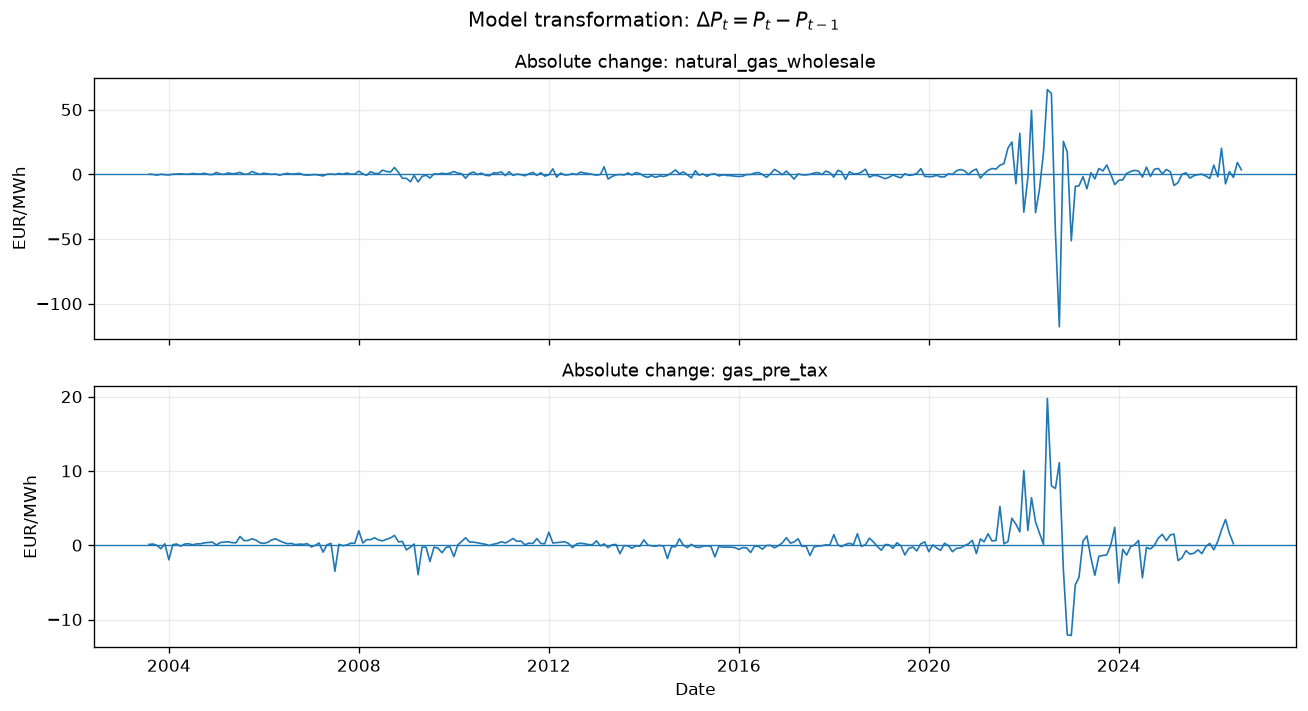

In [4]:
prep = prepare_bvar_panel(levels, p=P, variables=VARIABLES)

transformation_summary = pd.Series({
    "balanced_change_start": prep["balanced_start"],
    "balanced_change_end": prep["balanced_end"],
    "balanced_changes": prep["n_balanced_changes"],
    "VAR_regression_observations": prep["n_regression_observations"],
    "ragged_edge_months": prep["n_ragged_months"],
    "latest_calendar_month": prep["last_calendar_date"],
})
display(style_numeric_table(transformation_summary.to_frame("value"), caption="Transformation and sample"))
display(style_numeric_table(prep["ragged"], caption="Ragged-edge absolute changes (EUR/MWh)"))
plot_absolute_differences(prep["differences"])
plt.show()

## 3. Model

### 3.1 Constant-coefficient BVAR

For $t=1,\ldots,T$,

$$
y_t=c+\sum_{\ell=1}^{p}B_{\ell}y_{t-\ell}+\nu_t,
\qquad p=12.
$$

Define

$$
x_t=
\begin{pmatrix}
1 & y_{t-1}' & \cdots & y_{t-p}'
\end{pmatrix}',
$$

and let $B$ collect the constant and lag coefficients. Then

$$
y_t=B'x_t+\nu_t.
$$

The coefficients are constant through time.

### 3.2 Time-varying covariance

$$
\Sigma_t
=
A^{-1}O_t\Lambda_tO_t'\left(A^{-1}\right)'.
$$

Under the ordering wholesale gas first,

$$
A=
\begin{pmatrix}
1&0\\
a_{21}&1
\end{pmatrix},
\qquad
\Lambda_t=
\begin{pmatrix}
\lambda_{1,t}&0\\
0&\lambda_{2,t}
\end{pmatrix},
\qquad
O_t=
\begin{pmatrix}
o_{1,t}&0\\
0&o_{2,t}
\end{pmatrix}.
$$

Each 𝜆 is the variance of structural shock j under normal conditions (moves slowly and persistently (transition prior = random walk) - regime like absorption). Each 𝑜 is a scale factor on the shock's standard deviation.
A is the the contemporaneous structure, time invariant and encodes the relation between structural innovations (i.e., So the wholesale error is purely its own structural shock, while the pre-tax error is its own shock plus a contemporaneous loading on the wholesale shock.)

In short, the target variance (gas_pre_tax) is its own variance plus the wholesale variance transmitted through the system.

Equivalently,

$$
\nu_t
=A^{-1}O_t\Lambda_t^{1/2}\varepsilon_t,
\qquad
\varepsilon_t\sim\mathcal{N}(0,I_2).
$$

### 3.3 Persistent stochastic volatility

Let $h_{j,t}=\log\lambda_{j,t}$. For each structural shock,

$$
h_{j,t}=h_{j,t-1}+\eta_{j,t},
\qquad
\eta_{j,t}\sim\mathcal{N}(0,\phi_j).
$$

### 3.4 Transitory outliers

$$
o_{j,t}=
\begin{cases}
1, & \text{with probability }1-p_j,\\
U[2,20], & \text{with probability }p_j.
\end{cases}
$$

The continuous outlier support is represented numerically by a configurable grid. Conditional on the structural residual and stochastic volatility, a candidate scale $o$ receives posterior weight proportional to

$$
\Pr(o\mid p_j)\,
\frac{1}{o}
\exp\left(
-\frac{u_{j,t}^{2}}{2\lambda_{j,t}o^{2}}
\right).
$$

Before the KSC volatility draw, the current structural residual is divided by the current outlier scale. This prevents a one-month extreme observation from being absorbed mechanically as persistent stochastic volatility.

## 4. Priors

The paper places a normal prior (Minnesota prior) on the constant-coefficient VAR slopes. Because the model is estimated in **absolute differences** (removed the unit-root-like persistence), the prior mean is the white-noise specification (mean = 0, no predictability) rather than a random walk (mean = 1, highly persistent). Statistically, a random walk in levels is white noise in differences:

$$
\widetilde{B}_0=0,
\qquad
\beta=\operatorname{vec}(B)
\sim
\mathcal{N}\!\left(\operatorname{vec}(\widetilde{B}_0),H\right).
$$

Let $i$ denote the equation, $j$ the lagged variable and $\ell$ the lag. The diagonal prior standard deviations are

$$
\sqrt{H_{r,i}}
=
\begin{cases}
\dfrac{\lambda_1}{\ell^{\lambda_3}},
& j=i, \\[1.2ex]
\dfrac{\sigma_i}{\sigma_j}
\dfrac{\lambda_1\lambda_2}{\ell^{\lambda_3}},
& j\neq i, \\[1.2ex]
\sigma_i\lambda_4,
& \text{constant in equation } i.
\end{cases}
$$

Here $\sigma_i$ is the residual standard deviation from a preliminary AR(1) fitted to transformed variable $i$.

- $\lambda_1$ controls overall tightness;
- $\lambda_2$ adds shrinkage to cross-variable lags;
- $\lambda_3$ makes the prior tighter at longer lags; => shrinkage increase toward the prior mean = less significance in the model for latter coefficients.
- $\lambda_4$ controls the diffuse constant prior.

The ratio $\sigma_i/\sigma_j$ already protects the Minnesota block against multiplicative unit changes. Expressing both gas prices in EUR/MWh additionally makes the contemporaneous coefficient prior

$$
a_{21}\sim\mathcal{N}(0,V_a),
\qquad
V_a=10,
$$

naturally scaled. The coefficient $a_{21}$ describes the contemporaneous relation between reduced-form innovations; it is not by itself the full dynamic pass-through.

The remaining priors are

$$
\phi_j\sim\operatorname{IG}(a_{\phi},b_{\phi}),
\qquad
h_{j,0}\sim\mathcal{N}(m_{h,j},V_{h,0}),
\qquad
p_j\sim\operatorname{Beta}(a_p,b_p).
$$

𝜙𝑗 tunes how fast persistent volatility moves (i.e., step size of the volatility random walk), IG support (0,∞) ; pj tunes how often transitory spikes occur, Beta support (0,1).

The outlier prior is calibrated through

$$
\frac{a_p}{a_p+b_p}=\frac{1}{48},
\qquad
a_p+b_p=120,
$$

which gives $a_p=2.5$ and $b_p=117.5$.

,symbol,value,interpretation
Overall tightness,lambda1,0.20,overall coefficient tightness
Cross-lag tightness,lambda2,0.50,additional cross-lag tightness
Lag decay,lambda3,1.00,lag-decay exponent
Constant scale,lambda4,10.00,constant prior scale


,value,interpretation
A prior variance,10.00,variance of the contemporaneous A coefficient
phi prior mean,0.02,prior mean of volatility-of-volatility variance
outlier alpha,2.50,Beta prior outlier pseudo-count
outlier beta,117.50,Beta prior regular-observation pseudo-count
outlier prior mean,0.02,expected monthly outlier probability
outlier prior concentration,120.00,Beta prior concentration


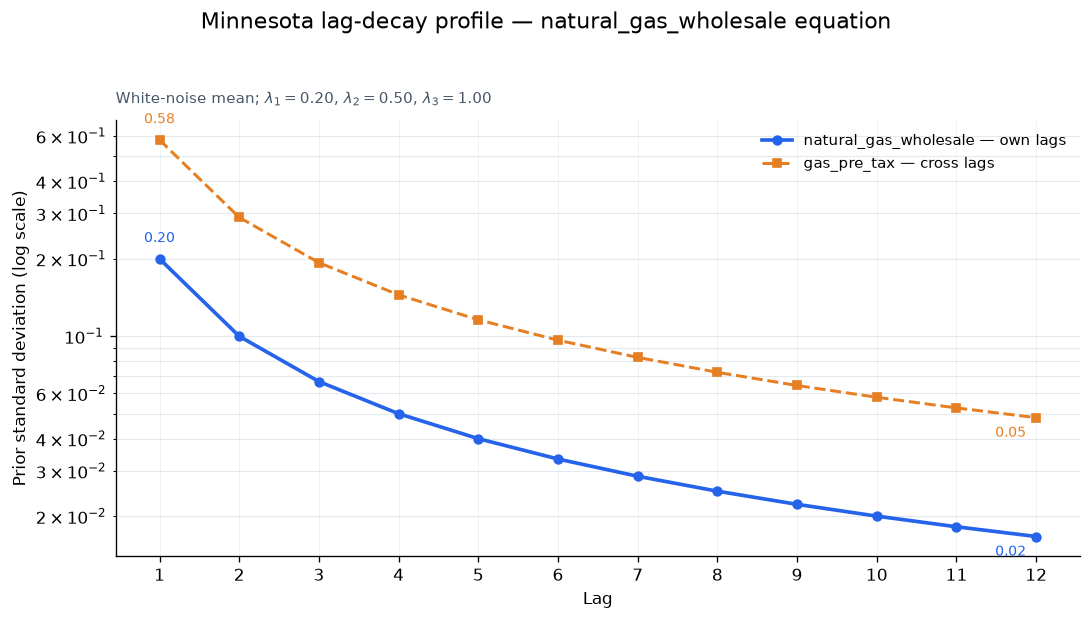

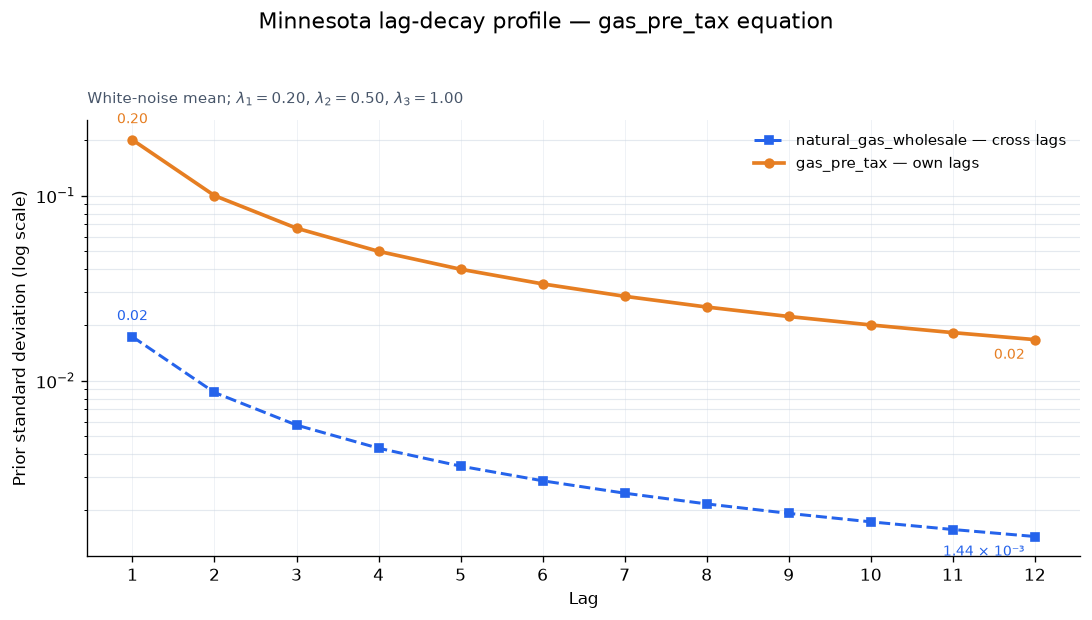

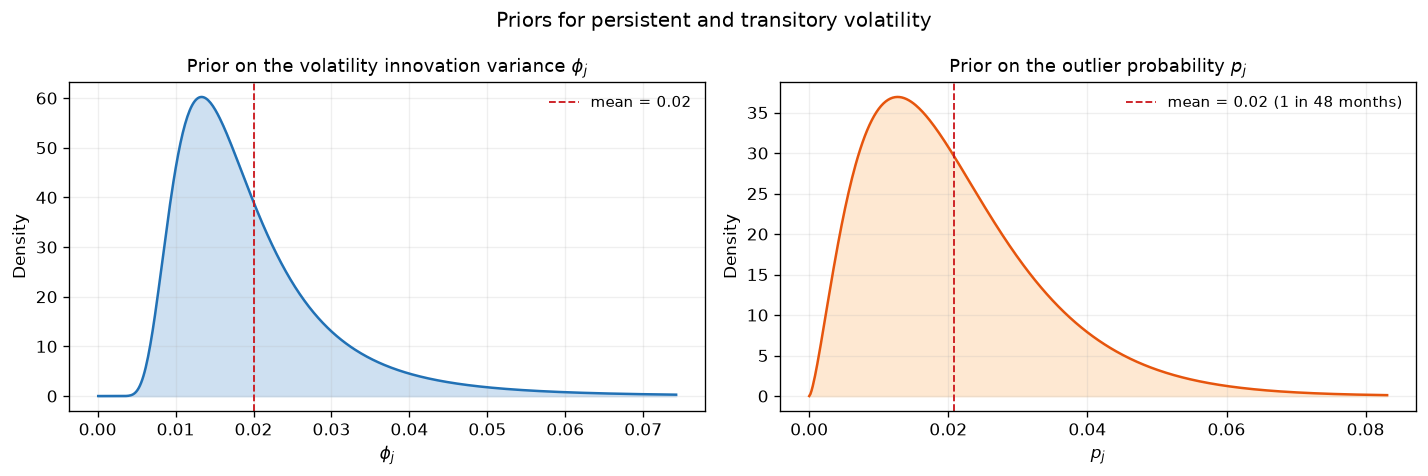

In [5]:
prior_config = BVARSVOPriorConfig(
    lambda1=0.20,
    lambda2=0.50,
    lambda3=1.00,
    lambda4=10.0,
    a_prior_var=10.0,
    phi_prior_mean=0.02,
    phi_prior_df=10.0,
    h0_var=4.0,
    outlier_mean_frequency=1.0 / 48.0,
    outlier_prior_observations=120.0,
    outlier_grid_min=2.0,
    outlier_grid_max=20.0,
    outlier_grid_step=1.0,
    ksc_offset_scale=1e-6,
)
prior = make_bvar_svo_prior(prep, prior_config)

minnesota_table = pd.DataFrame({
    "symbol": [r"lambda1", r"lambda2", r"lambda3", r"lambda4"],
    "value": [
        prior_config.lambda1,
        prior_config.lambda2,
        prior_config.lambda3,
        prior_config.lambda4,
    ],
    "interpretation": [
        "overall coefficient tightness",
        "additional cross-lag tightness",
        "lag-decay exponent",
        "constant prior scale",
    ],
}, index=["Overall tightness", "Cross-lag tightness", "Lag decay", "Constant scale"])

other_prior_table = pd.DataFrame({
    "value": [
        prior_config.a_prior_var,
        prior_config.phi_prior_mean,
        prior["outlier_alpha"],
        prior["outlier_beta"],
        prior["outlier_alpha"] / (prior["outlier_alpha"] + prior["outlier_beta"]),
        prior_config.outlier_prior_observations,
    ],
    "interpretation": [
        "variance of the contemporaneous A coefficient",
        "prior mean of volatility-of-volatility variance",
        "Beta prior outlier pseudo-count",
        "Beta prior regular-observation pseudo-count",
        "expected monthly outlier probability",
        "Beta prior concentration",
    ],
}, index=[
    "A prior variance",
    "phi prior mean",
    "outlier alpha",
    "outlier beta",
    "outlier prior mean",
    "outlier prior concentration",
])

display(style_numeric_table(minnesota_table, caption="Minnesota hyperparameters"))
display(style_numeric_table(other_prior_table, caption="SV, contemporaneous and outlier priors"))

# Only the non-redundant lag-decay profile is plotted. Prior means are all zero
# and are therefore documented in the markdown rather than shown as a heatmap.
prior_figures = plot_minnesota_prior_by_equation(prior, VARIABLES, P)
for equation, figure in prior_figures.items():
    display(figure)
    plt.close(figure)

plot_phi_and_outlier_priors(prior)
plt.show()

Minnesota belief is recent history is informative, remote lags are noise: recent lags are data-driven (loose priors), distant lags are shrunk to zero almost regardless of what the data say.
But, for the pre tax equation, we can see that the scale ratio (wholesale price more volatil (en différences mensuelles) than the retail price) is what pushes the orange curve (more volatile) above the blue, overpowering the λ₂ > λ1  shrinkage. Polynomial decay governed by λ₃ (power law).
In this configuration, the default expectation is smooth-persistent vol and rare outliers.

## 5. Likelihood

Conditional on $B$, $A$, the volatility path $H=\{h_t\}$ and the outlier scales $O=\{O_t\}$,

$$
y_t\mid B,A,H,O
\sim
\mathcal{N}\left(B'x_t,\Sigma_t\right),
$$

where

$$
\Sigma_t
=
A^{-1}O_t\Lambda_tO_t'\left(A^{-1}\right)'.
$$

The conditional log-likelihood is

$$
\log p(Y\mid B,A,H,O)
=
-\frac{1}{2}
\sum_{t=1}^{T}
\left[
N\log(2\pi)
+\log|\Sigma_t|
+\nu_t'\Sigma_t^{-1}\nu_t
\right].
$$

Conditional Gaussianity gives tractable Gibbs blocks, even though the marginal residual distribution is heteroskedastic and heavy-tailed.

## 6. Posterior and Gibbs sampler

The posterior kernel is

$$
\begin{aligned}
p(B,A,H,\Phi,O,p\mid Y)
\propto{}&
 p(Y\mid B,A,H,O)\,p(B)\,p(A)\\
&\times p(H\mid\Phi)\,p(\Phi)\,p(O\mid p)\,p(p).
\end{aligned}
$$

One Gibbs sweep is:

1. **$B\mid A,H,O,Y$** — joint heteroskedastic GLS draw; redraw until the companion roots lie inside the unit circle.
2. **$A\mid B,H,O,Y$** — weighted Gaussian regression. For the second equation,

   $$
   -\nu_{2,t}=a_{21}\nu_{1,t}+e_{2,t},
   \qquad
   \operatorname{Var}(e_{2,t})=o_{2,t}^{2}\lambda_{2,t}.
   $$

 In short, the target variance (gas_pre_tax) is its own variance plus the wholesale variance transmitted through the system.
 
3. **$H\mid B,A,O,\Phi,Y$** — KSC mixture indicators followed by a joint FFBS draw of each log-volatility path.
4. **$\Phi\mid H$** — inverse-gamma draws from the log-volatility increments.
5. **$O\mid B,A,H,p,Y$** — posterior categorical draw over the regular state and the outlier-scale grid.
6. **$p\mid O$** — Beta posterior based on the newly drawn outlier indicators.

The stability restriction is imposed only in the coefficient block. Forecast draws are not filtered a second time for stability.

In [6]:
sampler_config = SamplerConfig(
    reps=6_000,
    burn=3_000,
    thin=1,
    seed=SEED,
    max_stability_tries=1_000,
    progress_every=500,
)

result = gibbs_bvar_sv_outlier(
    levels=levels,
    p=P,
    variables=VARIABLES,
    prior_config=prior_config,
    sampler_config=sampler_config,
)

print(f"Retained posterior draws: {result['n_draws']:,}")
print(f"B instability proposal rejection rate: {result['B_instability_rejection_rate']:.2%}")
display(style_numeric_table(
    pd.Series(dict(zip(VARIABLES, result["ksc_offsets"]))).to_frame("KSC offset"),
    caption="Adaptive KSC offsets",
))

iteration 500/6,000 | B instability rejection 0.00% | radius 0.8168
iteration 1,000/6,000 | B instability rejection 0.00% | radius 0.8758
iteration 1,500/6,000 | B instability rejection 0.00% | radius 0.8386
iteration 2,000/6,000 | B instability rejection 0.00% | radius 0.8320
iteration 2,500/6,000 | B instability rejection 0.00% | radius 0.8115
iteration 3,000/6,000 | B instability rejection 0.00% | radius 0.7773
iteration 3,500/6,000 | B instability rejection 0.00% | radius 0.8347
iteration 4,000/6,000 | B instability rejection 0.00% | radius 0.7980
iteration 4,500/6,000 | B instability rejection 0.00% | radius 0.7937
iteration 5,000/6,000 | B instability rejection 0.00% | radius 0.7727
iteration 5,500/6,000 | B instability rejection 0.00% | radius 0.7977
iteration 6,000/6,000 | B instability rejection 0.00% | radius 0.7942
Retained posterior draws: 3,000
B instability proposal rejection rate: 0.00%


,KSC offset
natural_gas_wholesale,4.35 × 10⁻⁶
gas_pre_tax,1.79 × 10⁻⁷


## 7. Results

### 7.1 Posterior coefficients — equations shown separately


natural_gas_wholesale equation


,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
regressor,,,,,,,,,,
const,0.00,115.39,0.10,0.10,0.09,-0.05,7.98 × 10⁻³,0.19,0.26,555.04
natural_gas_wholesale L1,0.00,0.20,0.10,0.10,0.07,-5.70 × 10⁻³,0.04,0.17,0.22,646.95
gas_pre_tax L1,0.00,0.58,0.04,0.03,0.15,-0.19,-0.11,0.19,0.31,946.85
natural_gas_wholesale L2,0.00,0.10,0.01,0.01,0.06,-0.08,-0.04,0.07,0.10,1068.02
gas_pre_tax L2,0.00,0.29,0.03,0.03,0.13,-0.18,-0.10,0.15,0.24,1317.24
natural_gas_wholesale L3,0.00,0.07,0.11,0.11,0.05,0.03,0.06,0.15,0.18,1349.80
gas_pre_tax L3,0.00,0.19,0.06,0.06,0.12,-0.13,-0.06,0.18,0.26,1204.77
natural_gas_wholesale L4,0.00,0.05,-0.01,-0.01,0.04,-0.08,-0.05,0.03,0.05,1954.72
gas_pre_tax L4,0.00,0.14,0.03,0.03,0.10,-0.14,-0.07,0.13,0.19,1938.61


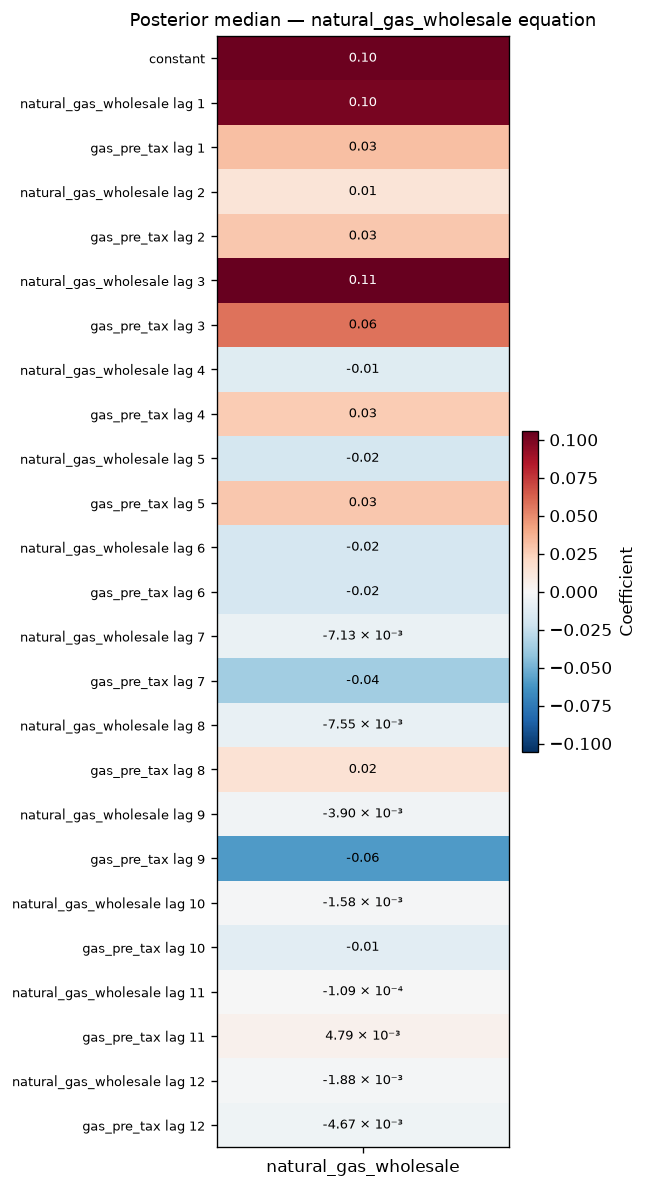

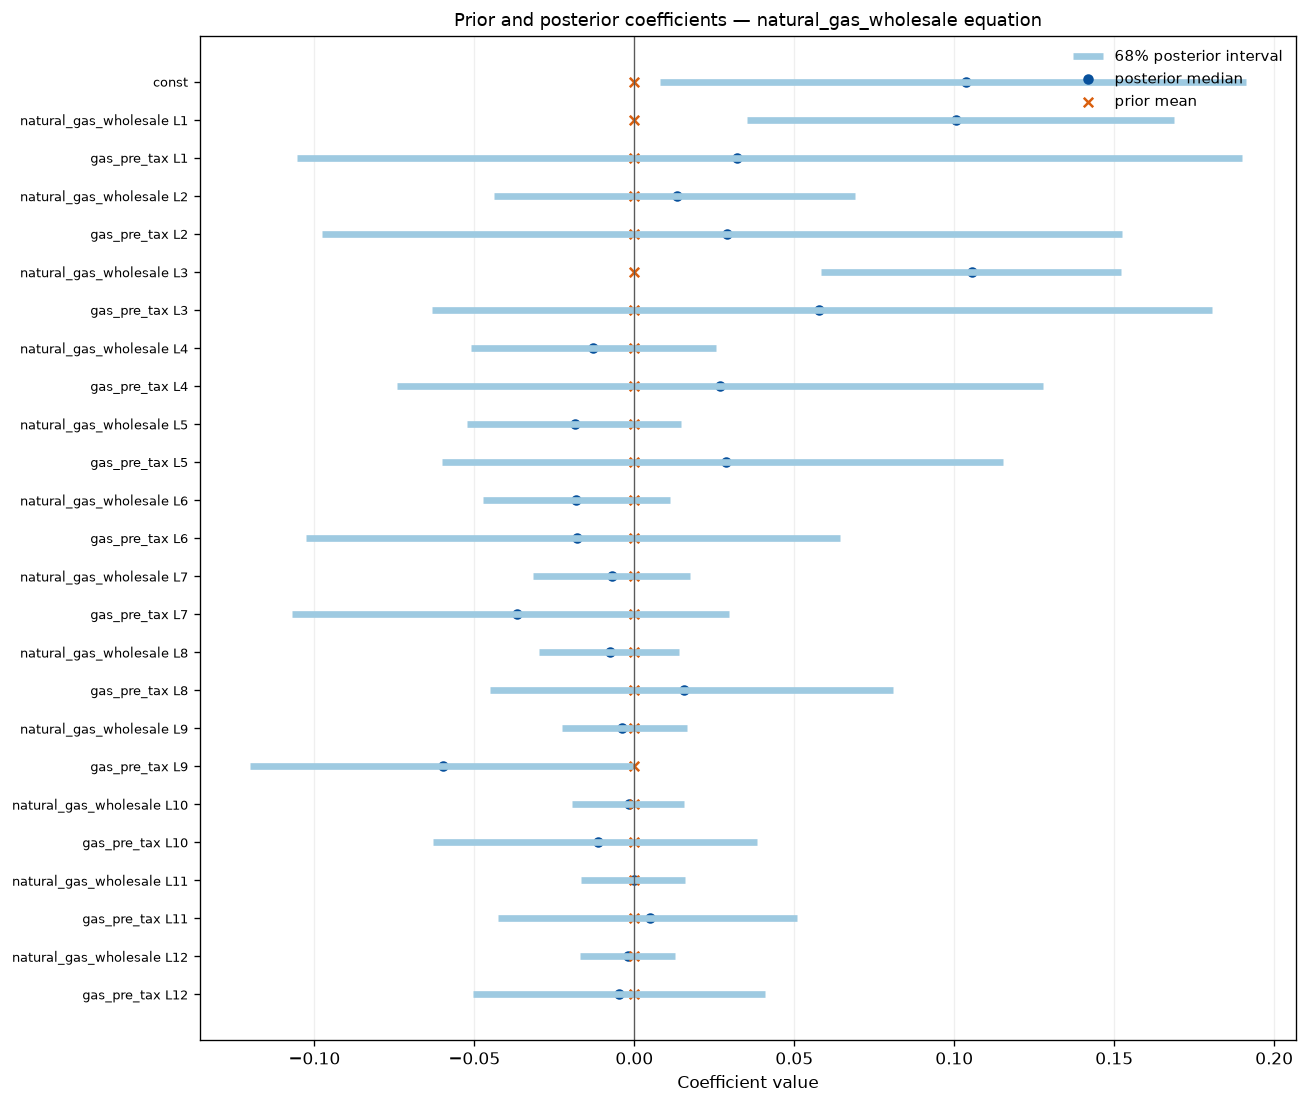


gas_pre_tax equation


,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
regressor,,,,,,,,,,
const,0.00,19.92,0.12,0.12,0.03,0.06,0.09,0.16,0.18,76.01
natural_gas_wholesale L1,0.00,0.02,0.04,0.04,6.19 × 10⁻³,0.03,0.04,0.05,0.05,1700.18
gas_pre_tax L1,0.00,0.20,0.15,0.15,0.03,0.10,0.12,0.18,0.20,895.31
natural_gas_wholesale L2,0.00,8.63 × 10⁻³,0.02,0.02,6.10 × 10⁻³,0.01,0.02,0.03,0.03,1451.09
gas_pre_tax L2,0.00,0.10,0.11,0.11,0.03,0.07,0.08,0.14,0.15,1794.71
natural_gas_wholesale L3,0.00,5.75 × 10⁻³,1.81 × 10⁻⁴,8.05 × 10⁻⁵,5.04 × 10⁻³,-8.25 × 10⁻³,-4.87 × 10⁻³,5.21 × 10⁻³,8.25 × 10⁻³,2406.34
gas_pre_tax L3,0.00,0.07,0.07,0.07,0.04,0.02,0.04,0.11,0.13,231.07
natural_gas_wholesale L4,0.00,4.32 × 10⁻³,2.52 × 10⁻⁴,3.21 × 10⁻⁴,3.67 × 10⁻³,-5.71 × 10⁻³,-3.36 × 10⁻³,3.76 × 10⁻³,6.27 × 10⁻³,2512.12
gas_pre_tax L4,0.00,0.05,-0.01,-0.02,0.03,-0.06,-0.04,0.01,0.03,1078.48


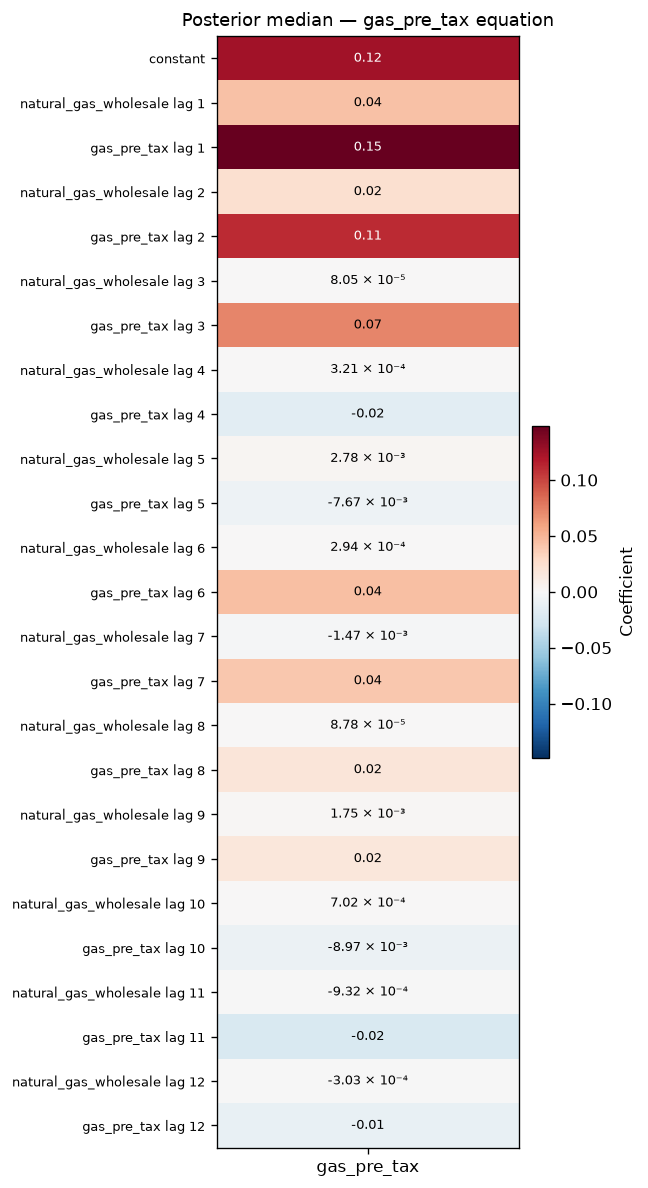

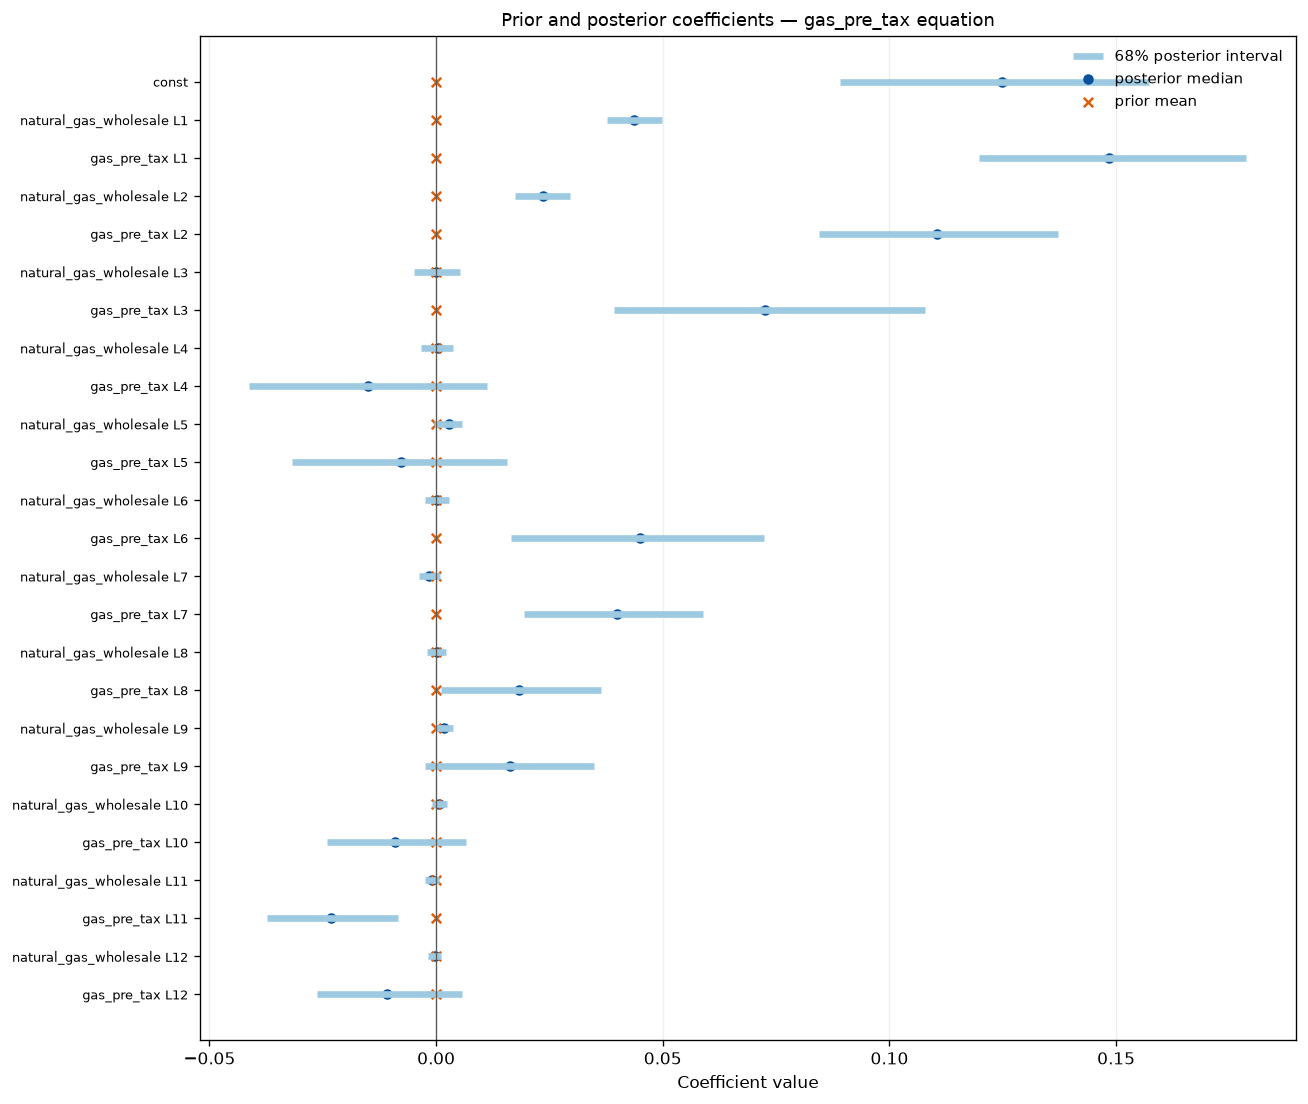

In [7]:
coefficient_tables = coefficient_posterior_tables(result)

for equation in VARIABLES:
    print(f"\n{equation} equation")
    display(style_numeric_table(
        coefficient_tables[equation],
        caption=f"Posterior coefficients — {equation} equation",
    ))
    plot_coefficient_heatmap(result, equation=equation)
    plot_shrinkage_comparison(result, equations=[equation])
    plt.show()

Across both equations the coefficients are small and, for the most part, weakly identified — visibly more so in the `natural_gas_wholesale` equation, where nearly every credible interval straddles zero. This is expected : in absolute differences the wholesale hub price is close to white noise (an efficient market leaves little month-to-month predictability), so the data cannot pin its coefficients and the posteriors stay diffuse around the prior. The `gas_pre_tax` equation is the exception that identifies cleanly: its own short lags carry a genuine, data-driven signal — the L1 own-lag has a posterior median of 0.15 with a [0.10, 0.20] 90% credible interval (and [0.12, 0.18] at 68%), so the interval excludes zero and the coefficient is robustly positive. i.e., *momentum in the changes*: a +1 move in the pre-tax price last month is associated with a further +0.15 this month, ceteris paribus . 

In the identification perspective: the collapse from a prior SD of 0.20 to a posterior SD of 0.03 on that same coefficient shows the data speaking, whereas the distant lags (e.g. `natural_gas_wholesale` L12, prior SD 1.44×10⁻³ → posterior SD 1.39×10⁻³) are essentially untouched by the sample and shrink to zero because the Minnesota prior forces them there, not because the data say so. 

The individual β's are in any case only inputs: the economic pass-through should be read off the cumulative impulse responses, not any single coefficient. 

ESS advocates for a longer chain signaled by the low values on `const` and `gas_pre_tax`.

### 7.2 Stochastic volatility and outliers

The volatility block is easiest to read through the decomposition

$$
\text{total SD}_{j,t}
=
o_{j,t}\sqrt{\lambda_{j,t}},
\qquad
\text{persistent SD}_{j,t}
=
\sqrt{\lambda_{j,t}}.
$$

Here $o_{j,t}=1$ in regular periods and $o_{j,t}\in[2,20]$ during a transitory outlier episode.

,,posterior_probability
date,,
2009-04-01,gas_pre_tax,1.00
2007-07-01,gas_pre_tax,1.00
2023-01-01,gas_pre_tax,1.00
2022-07-01,gas_pre_tax,1.00
2022-10-01,gas_pre_tax,1.00
2022-12-01,gas_pre_tax,1.00
2022-01-01,gas_pre_tax,1.00
2012-01-01,gas_pre_tax,1.00
2008-01-01,gas_pre_tax,1.00


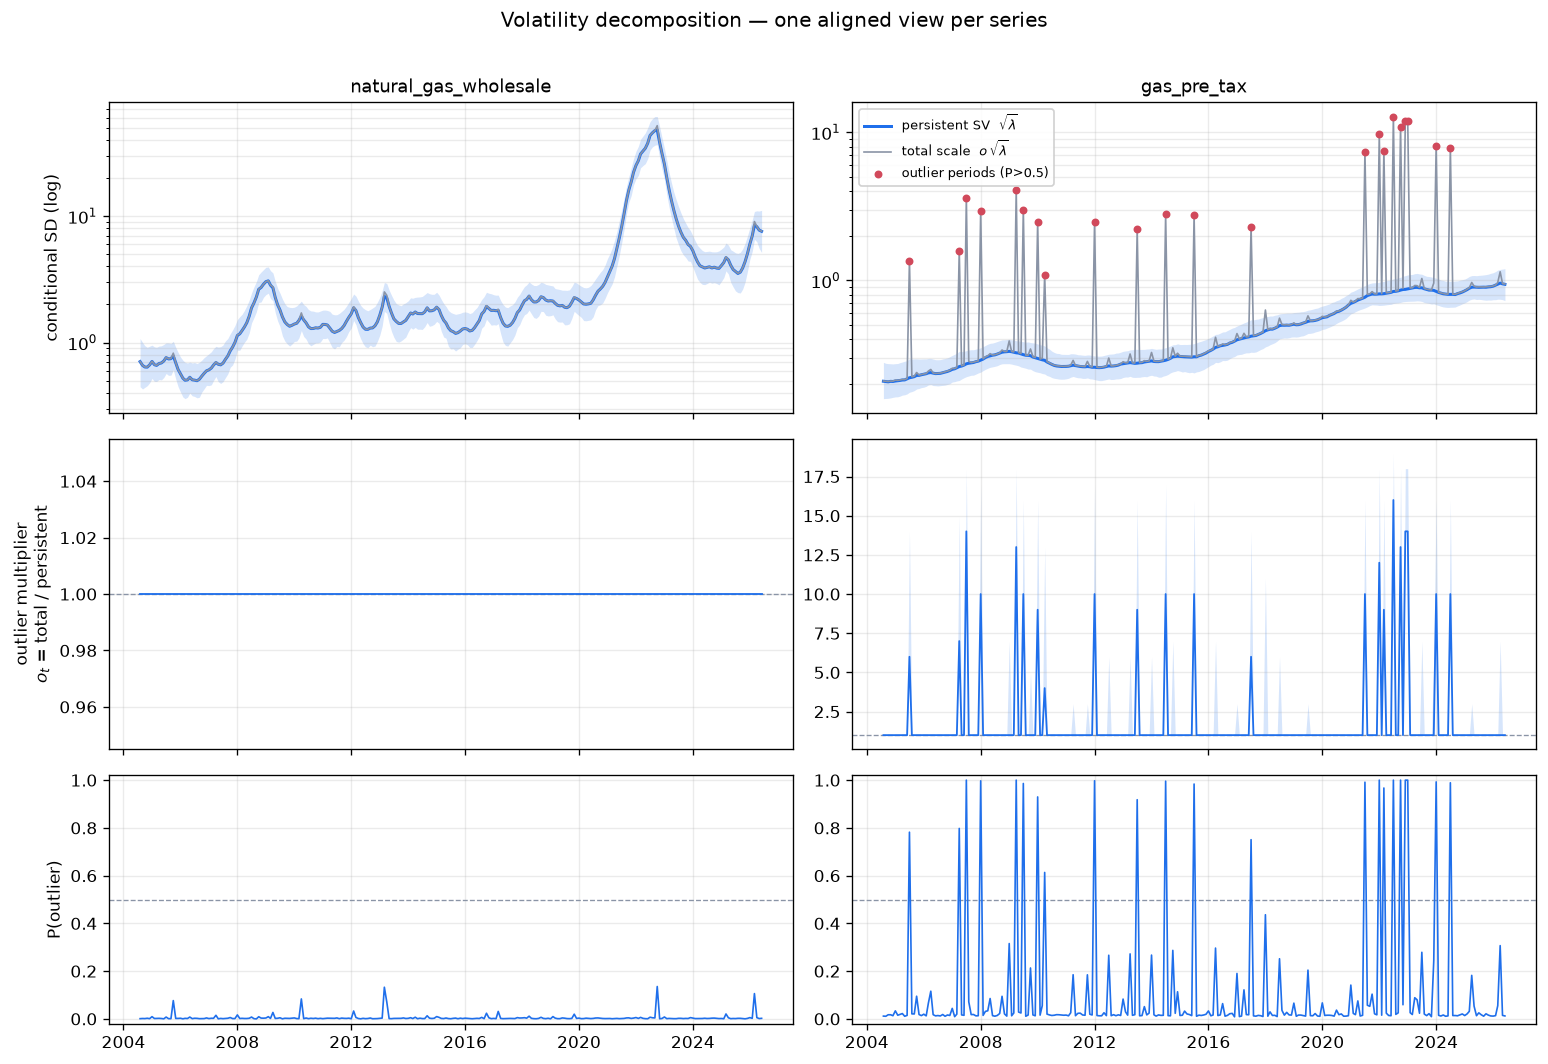

In [8]:
outlier_probability = posterior_outlier_probability(result)
important_outliers = (
    outlier_probability.stack()
    .rename("posterior_probability")
    .loc[lambda s: s >= 0.50]
    .sort_values(ascending=False)
    .to_frame()
)
display(style_numeric_table(
    important_outliers.head(30),
    caption="Dates with posterior outlier probability at least 50%",
))

plot_volatility_decomposition(result)
plt.show()


The absence of flagged outliers in `natural_gas_wholesale`, contrasted with the many in `gas_pre_tax`, is the model behaving as designed. Faced with a large residual, the sampler chooses between two channels: the persistent stochastic-volatility level Λₜ (a random walk on log-vol, which stays elevated once raised) and the transitory outlier factor Oₜ (i.i.d., a one-month spike that reverts). Which one absorbs a big move depends on whether large moves *cluster*. The wholesale hub price moves in regimes — 2021–2023 was turbulent for months on end — so its SV level simply rises to meet those moves and nothing transitory. 
The consumer pre-tax price is viscous most of the time (sticky retail prices) and then makes discrete one-month resets against that calm baseline, which is exactly the profile the outlier channel exists to catch. 

The key point is that an outlier is defined *relative to the local persistent σ*: for wholesale, σ climbs alongside its own big moves, so a large raw move is not a large *standardised* one — nothing is anomalous relative to the prevailing regime. This shows up in the posterior vol-of-vol φ, which the data pushed high for wholesale (a flexible SV that hugs the structure) and left small for pre-tax (a smooth baseline the spikes overflow), even though both started from the same 0.02 prior. 
No special treatment is warranted: forcing outliers onto wholesale would misspecify a genuinely regime-switching process.

### 7.3 Standardized structural residuals

,mean,sd,skewness,excess_kurtosis,acf_1,maximum_absolute
variable,,,,,,
natural_gas_wholesale,-4.71 × 10⁻³,0.94,0.04,-0.29,0.03,2.53
gas_pre_tax,-0.02,1.00,0.19,0.45,0.12,2.84


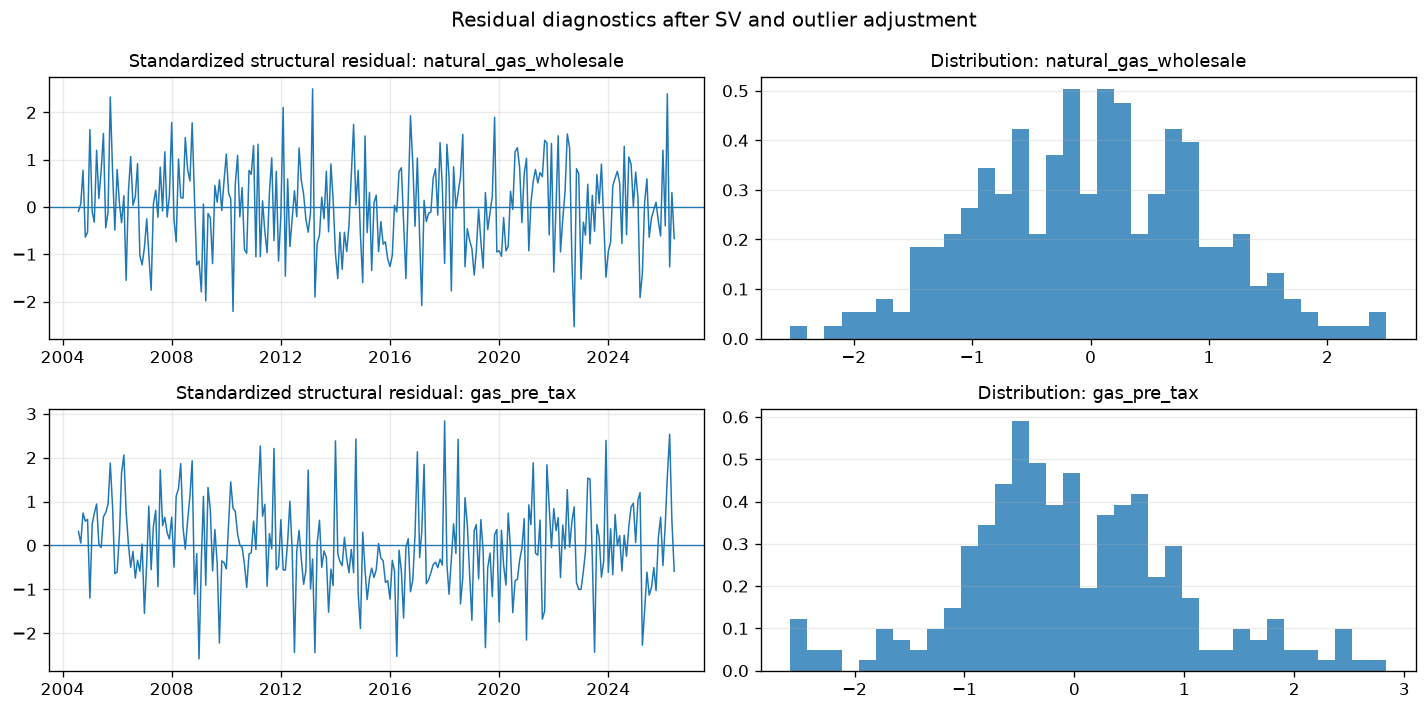

In [19]:
display(style_numeric_table(
    residual_diagnostic_table(result),
    caption="Standardized structural-residual diagnostics",
))
plot_standardized_residuals(result)
plt.show()

After the SV and outlier adjustment, the standardized structural residuals are close to well-behaved: no visible time pattern (acf_1 ≈ 0.03 / 0.12), unit scale (sd ≈ 0.94 / 1.00) and near-zero mean, and maximum absolute values around 2.5–2.8 — i.e. no surviving extremes. For `natural_gas_wholesale` the residuals are essentially Gaussian (skewness ≈ 0.04, excess kurtosis ≈ −0.29, if anything slightly thin-tailed), which confirms the SV correctly absorbs its volatility — including the 2022 peak — and legitimises the absence of flagged outliers. For `gas_pre_tax`, the standardization also works but is less clean: mild right-skew (0.19) and positive excess kurtosis (0.45) leave a slightly heavier right tail (max abs 2.84, acf_1 = 0.12), suggesting a few consumer-price resets are not fully captured. Overall the method works, but the pre-tax residuals are not perfectly Gaussian.

### 7.3 Ragged-edge nowcast

The parameter posterior is estimated only on the balanced block. The final incomplete months are then handled in companion form with the Durbin–Koopman simulation smoother.

Let

$$
\alpha_t=
\begin{pmatrix}
y_t'&y_{t-1}'&\cdots&y_{t-p+1}'
\end{pmatrix}'.
$$

The state transition is

$$
\alpha_{t+1}=c^{*}+F(B)\alpha_t+S\nu_{t+1},
\qquad
S=
\begin{pmatrix}
I_2\\
0
\end{pmatrix}.
$$

Released wholesale changes enter as observations. Missing recent `gas_pre_tax` changes remain unobserved and are drawn conditionally. 
This is a **nowcast** of the ragged edge.

**Visual convention.** Observed values are shown in dark grey, ragged-edge nowcasts in orange, and genuine future forecasts in blue. Each simulated segment is anchored to the preceding observed or draw-specific endpoint, so no artificial plotting gap is introduced.


Forecast origin: 2026-08-01
Forecast horizon used: 4 months


,status,observed,q05,q16,median,q84,q95
date,,,,,,,
2026-07-01,nowcast,—,83.26,84.37,85.49,86.60,87.54
2026-08-01,nowcast,—,80.11,84.38,86.31,88.10,91.50


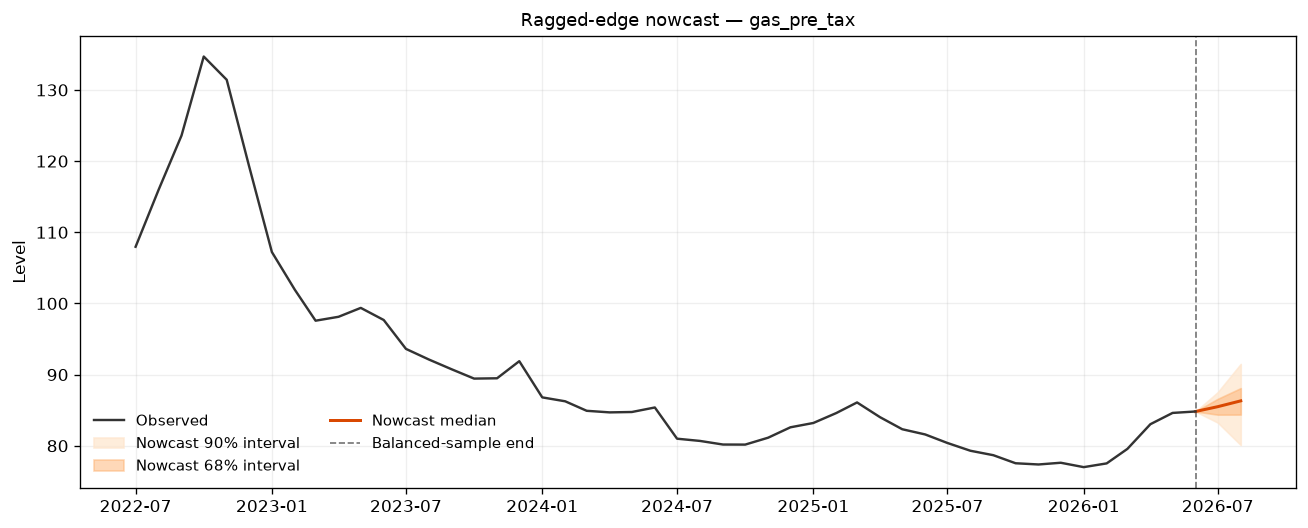

,status,observed,q05,q16,median,q84,q95
date,,,,,,,
2026-07-01,observed / conditioned,53.97,53.97,53.97,53.97,53.97,53.97
2026-08-01,observed / conditioned,57.40,57.40,57.40,57.40,57.40,57.40


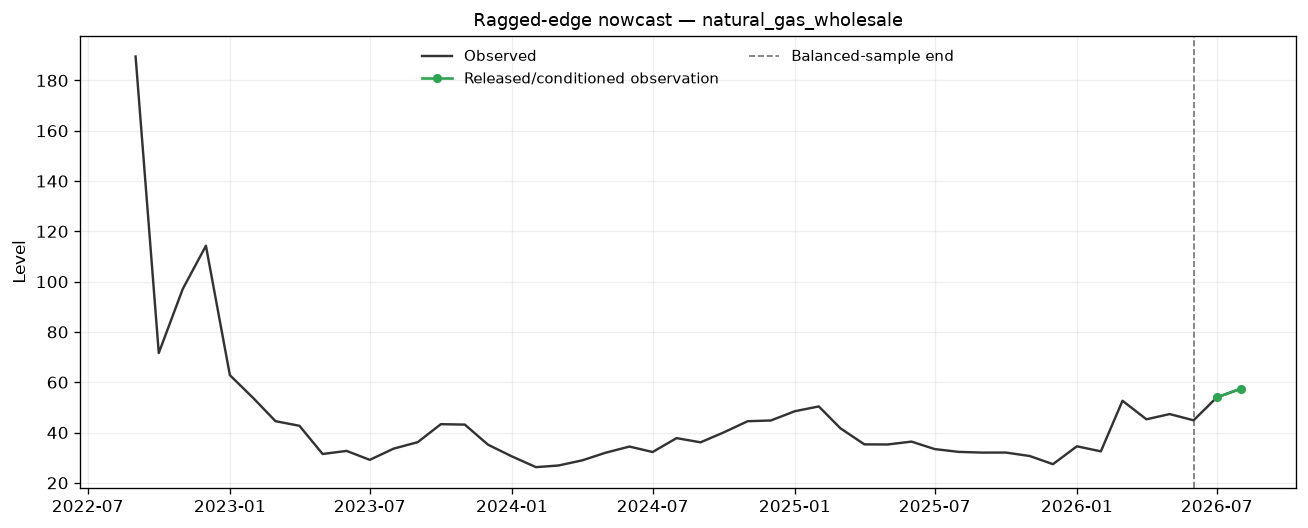

In [9]:
# The forecast need only cover 1 month, 3 months and the relevant year-end.
FORECAST_ORIGIN = prep["last_calendar_date"]
MONTHS_TO_YEAR_END = 12 - FORECAST_ORIGIN.month
if MONTHS_TO_YEAR_END == 0:
    MONTHS_TO_YEAR_END = 12  # December origin -> next December year-end.
H = max(3, MONTHS_TO_YEAR_END)
FORECAST_DRAWS = min(1_000, result["n_draws"])

forecast_unconditional = forecast_bvar_sv_outlier(
    result,
    H=H,
    n_draws=FORECAST_DRAWS,
    simulate_future_outliers=True,
    seed=2026,
)

print(f"Forecast origin: {FORECAST_ORIGIN.date()}")
print(f"Forecast horizon used: {H} months")

# The consumer gas price is the economically relevant ragged-edge nowcast.
gas_nowcast_table = nowcast_summary_table(
    forecast_unconditional,
    observed_levels=levels,
    variable="gas_pre_tax",
    missing_only=True,
)
if gas_nowcast_table.empty:
    print("No missing gas_pre_tax observation is present in the ragged edge.")
else:
    display(style_numeric_table(gas_nowcast_table, caption="Ragged-edge nowcast — gas_pre_tax (EUR/MWh)"))

plot_nowcast_fan(
    forecast_unconditional,
    historical_levels=levels,
    variable="gas_pre_tax",
)
plt.show()

# Wholesale observations in the ragged edge are conditioned exactly; this table
# is a transparent verification rather than a second nowcast.
wholesale_tail_table = nowcast_summary_table(
    forecast_unconditional,
    observed_levels=levels,
    variable="natural_gas_wholesale",
    missing_only=False,
)
if not wholesale_tail_table.empty:
    display(style_numeric_table(wholesale_tail_table, caption="Conditioned wholesale observations (EUR/MWh)"))
    plot_nowcast_fan(
        forecast_unconditional,
        historical_levels=levels,
        variable="natural_gas_wholesale",
    )
    plt.show()

### 7.4 Short unconditional forecasts

Forecasts are reported in levels at three operational horizons:

$$
h\in\{1\text{ month},\ 3\text{ months},\ \text{year-end}\}.
$$

Year-end is defined relative to the forecast origin. When the origin is December, the target is December of the following year. Future log-volatility follows its random walk and future outlier states are simulated from the posterior outlier frequency, so the reported intervals are full predictive intervals.


Short-horizon level forecast: natural_gas_wholesale


,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,41.35,49.59,57.42,65.36,75.13
3 months,3.00,2026-11-01,26.20,43.07,58.45,74.18,92.30
End of 2026,4.00,2026-12-01,15.91,39.86,58.19,76.71,96.69


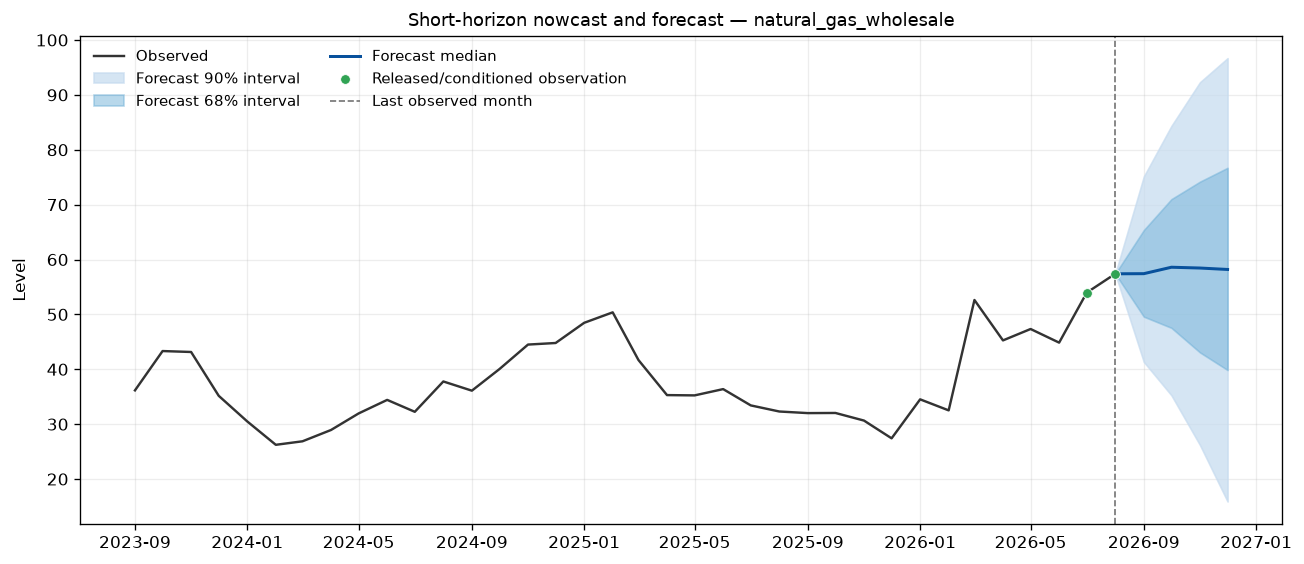


Short-horizon level forecast: gas_pre_tax


,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,77.37,84.27,87.13,89.73,96.59
3 months,3.00,2026-11-01,70.65,83.07,88.50,93.31,104.82
End of 2026,4.00,2026-12-01,68.66,82.39,89.21,95.62,109.44


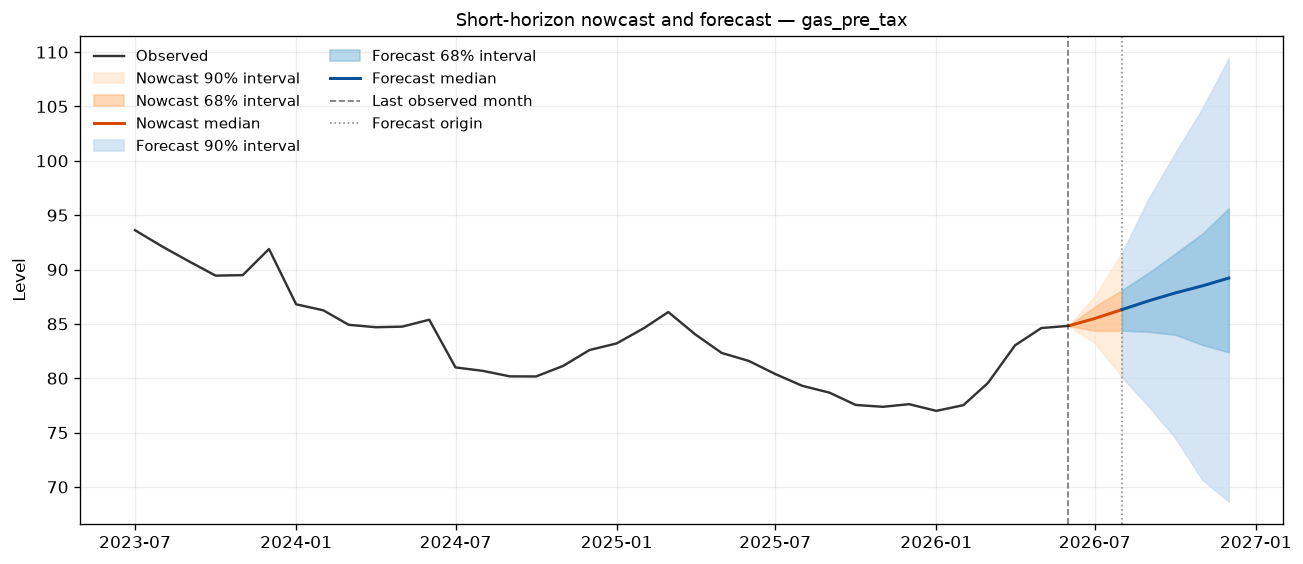

In [10]:
short_forecast_tables = {}
for variable in VARIABLES:
    print(f"\nShort-horizon level forecast: {variable}")
    table = forecast_horizon_table(forecast_unconditional, variable)
    short_forecast_tables[variable] = table
    display(style_numeric_table(
        table,
        caption=f"Unconditional level forecast — {variable} (EUR/MWh)",
    ))
    plot_short_forecast_fan(
        forecast_unconditional,
        historical_levels=levels,
        variable=variable,
    )
    plt.show()

### 7.5 Conditional forecast

The scenario fixes a future **level path** for wholesale gas. The path is converted into exact absolute changes and entered as observed future values in the state-space representation; the consumer gas price remains missing and is drawn conditionally.

The illustrative scenario is a permanent 10% increase relative to the latest observed wholesale price:

$$
P_{T+h}^{\mathrm{wholesale,scenario}}
=1.10\,P_T^{\mathrm{wholesale}},
\qquad h=1,\ldots,H.
$$

This is a conditional-forecast sensitivity exercise, not a one-period structural impulse response.

Maximum absolute condition error: 1.63 × 10⁻¹³


,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,77.87,84.49,87.23,89.77,95.46
3 months,3.00,2026-11-01,73.45,84.07,88.96,93.43,104.12
End of 2026,4.00,2026-12-01,72.27,84.02,89.76,95.03,107.56


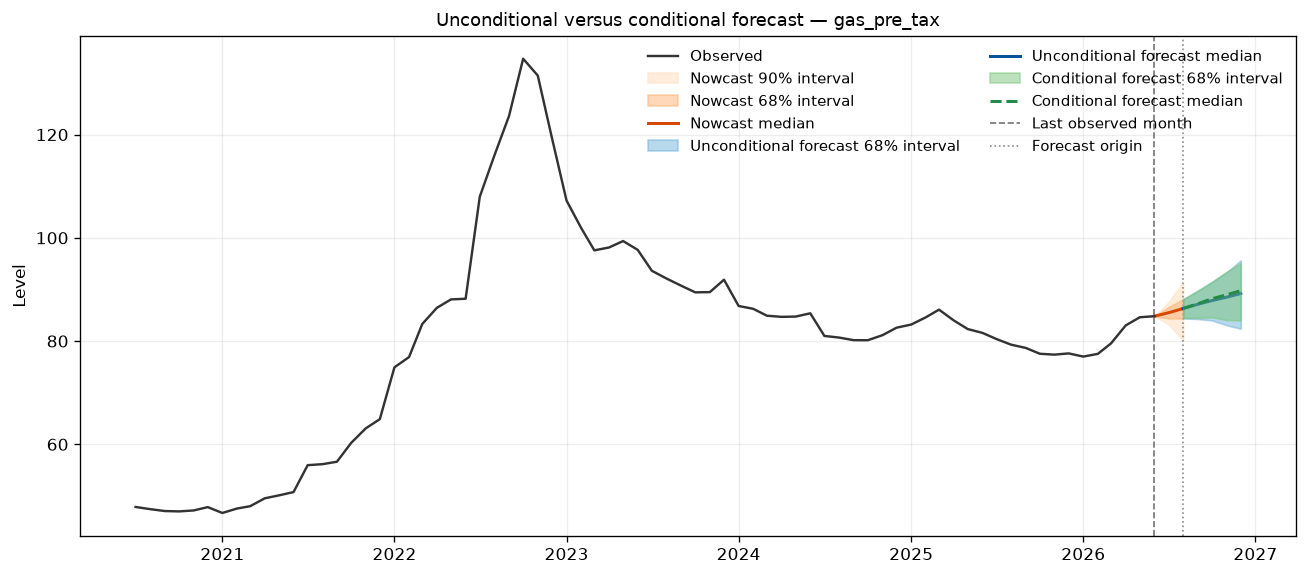

In [11]:
last_wholesale_level = levels["natural_gas_wholesale"].dropna().iloc[-1]
wholesale_up_10 = np.full(H, 1.10 * last_wholesale_level)

forecast_conditional = forecast_bvar_sv_outlier(
    result,
    H=H,
    level_conditions={"natural_gas_wholesale": wholesale_up_10},
    n_draws=FORECAST_DRAWS,
    simulate_future_outliers=True,
    seed=2026,
)

condition_error = np.max(
    np.abs(
        forecast_conditional["future_level_paths"][:, :, VARIABLES.index("natural_gas_wholesale")]
        - wholesale_up_10[None, :]
    )
)
print(f"Maximum absolute condition error: {format_number(condition_error)}")

display(style_numeric_table(
    forecast_horizon_table(forecast_conditional, "gas_pre_tax"),
    caption="Conditional gas_pre_tax forecast (EUR/MWh)",
))
plot_forecast_comparison(
    forecast_unconditional,
    forecast_conditional,
    historical_levels=levels,
    variable="gas_pre_tax",
)
plt.show()

### 7.6 Tax re-attribution and HICP gas forecast

The BVAR target and excise path are both expressed in EUR/MWh. The forecast is mapped back to the HICP gas index using

$$
P_t^{\mathrm{HICP\ gas}}
=
\frac{
\left(P_t^{\mathrm{gas,pre\text{-}tax}}+EXC_t^{\mathrm{EUR/MWh}}\right)
\left(1+VAT_t/100\right)
}{\widehat{\gamma}_{\mathrm{MWh}}}.
$$

Future VAT and excise are held at their latest published levels. The notebook first checks the exact numerical round trip

$$
P^{\mathrm{HICP}}
\rightarrow
P^{\mathrm{pre\text{-}tax}}
\rightarrow
P^{\mathrm{HICP}}.
$$

,value
observations,276.00
maximum_absolute_error,1.42 × 10⁻¹⁴
tolerance,1.00 × 10⁻¹⁰


HICP gas index — short-horizon forecast


,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,97.07,103.90,106.73,109.30,116.09
3 months,3.00,2026-11-01,90.42,102.71,108.08,112.84,124.24
End of 2026,4.00,2026-12-01,88.45,102.04,108.79,115.13,128.81


HICP gas year-on-year inflation — short-horizon forecast


,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,-1.31,5.63,8.51,11.12,18.03
3 months,3.00,2026-11-01,-6.85,5.81,11.35,16.25,27.99
End of 2026,4.00,2026-12-01,-9.11,4.86,11.80,18.32,32.37


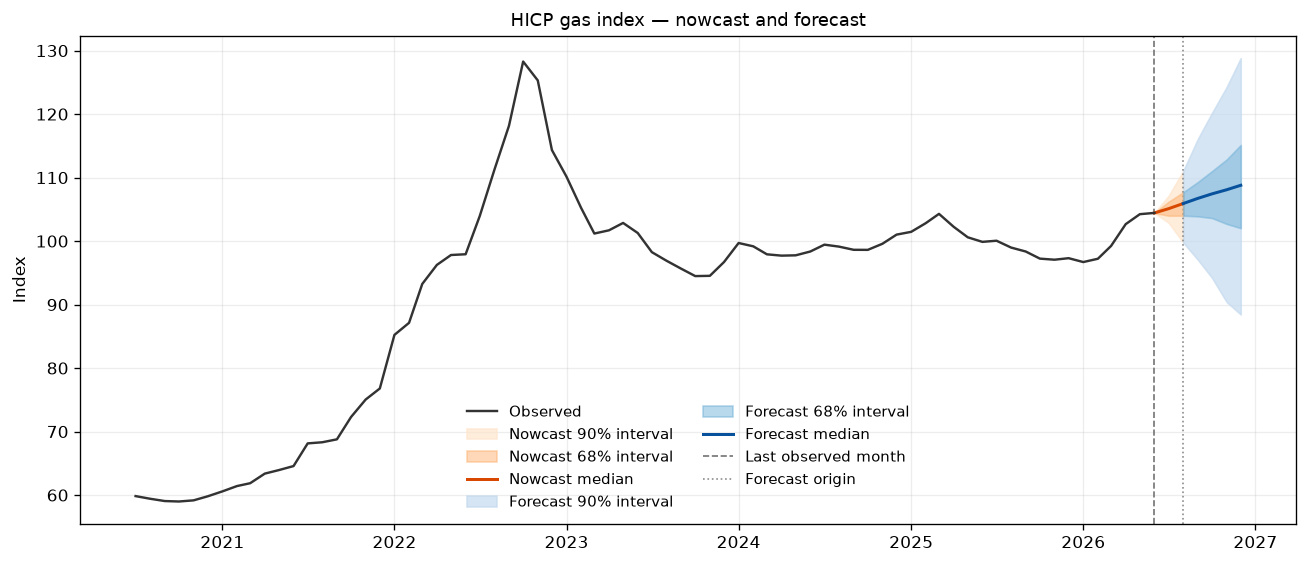

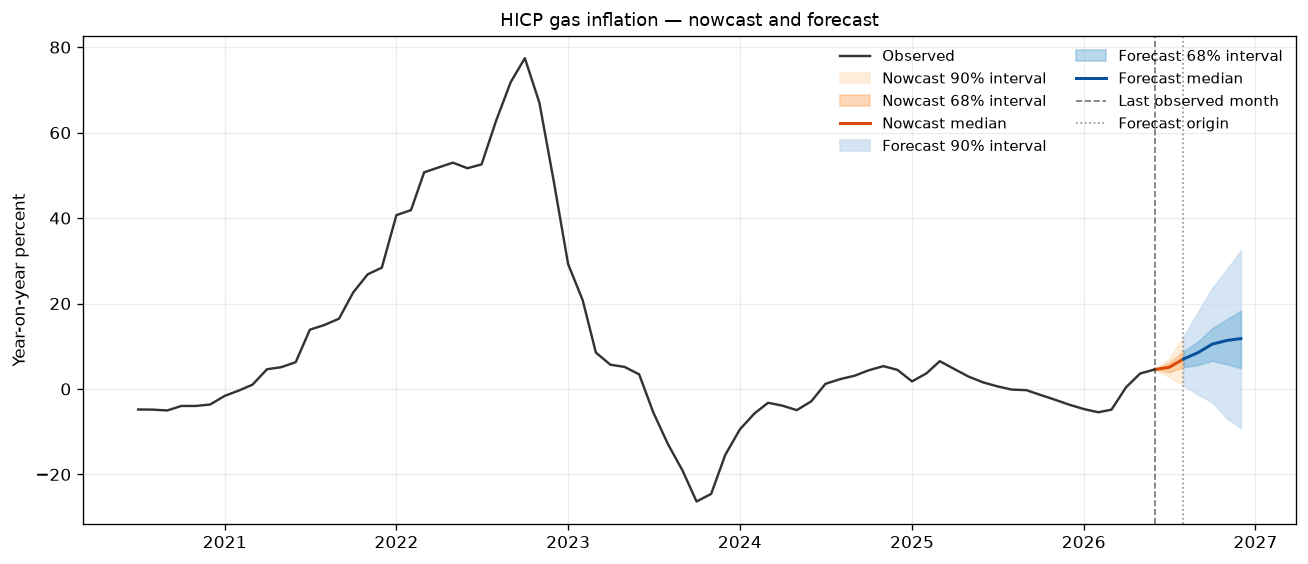

In [12]:
tax_context = None
try:
    tax_context = load_gas_tax_context(GAS_DATASET)
    display(style_numeric_table(
        validate_tax_round_trip(tax_context).to_frame("value"),
        caption="Tax construction round-trip check",
    ))

    hicp_unconditional = forecast_to_hicp_gas(
        forecast_unconditional,
        result,
        tax_context,
    )
    hicp_conditional = forecast_to_hicp_gas(
        forecast_conditional,
        result,
        tax_context,
    )

    print("HICP gas index — short-horizon forecast")
    display(style_numeric_table(
        path_horizon_table(
            hicp_unconditional["future_hicp_level_paths"],
            hicp_unconditional["future_dates"],
            forecast_unconditional["last_calendar_date"],
        ),
        caption="HICP gas index forecast",
    ))
    print("HICP gas year-on-year inflation — short-horizon forecast")
    display(style_numeric_table(
        path_horizon_table(
            hicp_unconditional["future_hicp_yoy_paths"],
            hicp_unconditional["future_dates"],
            forecast_unconditional["last_calendar_date"],
        ),
        caption="HICP gas year-on-year inflation forecast (%)",
    ))

    plot_hicp_forecast_fan(hicp_unconditional, kind="level")
    plot_hicp_forecast_fan(hicp_unconditional, kind="yoy")
    plt.show()
except (FileNotFoundError, KeyError) as exc:
    print("Tax re-attribution skipped:")
    print(exc)

The width of the forecast fan is driven by the volatility state at the forecast origin, not by the whole sample or the 2021–2023 cluster directly. Two distinct objects set the cone: √λ at the last observed month fixes the cone's starting height (read it off the right-most point of the persistent-SV line — note it ticks back up at the sample edge rather than sitting in the calm 2024–2025 trough, so we forecast from an already-elevated point), while the vol-of-vol φ sets the cone's rate of widening per step ahead. The turbulent cluster acts only indirectly — it is what pushed the posterior φ high, which is why the fan opens quickly. 

The target of the HICP forecast is gas_pre_tax, so the direct σ is the pre-tax √λ at the origin (~1), but the wholesale √λ (~7–8) still matters because wholesale drives pre-tax (contomporeneous coef). Concretely, the target's forecast variance has two channels: (a) its own future shocks ε₂, and (b) future wholesale shocks ε₁ transmitted into pre-tax via the contemporaneous loading a₂₁ and the cross-lags (since wholesale is the ~6× more volatile driver, channel (b) dominates the cone width.).

This is exactly why a conditional forecast that fixes the future wholesale path (on the TTF futures curve) tightens the interval so sharply: it replaces future ε₁ with a known path, removing channel (b) entirely and leaving only (a) plus parameter and volatility-path uncertainty.

### 7.7 Structural analysis: recursive and sign-restricted identification

The same posterior draws are used for three linked structural objects:

1. **Impulse responses (IRFs)** — the dynamic response of monthly price changes and, after cumulation, of price levels.
2. **Forecast error variance decomposition (FEVD)** — the share of forecast uncertainty attributable to each structural shock.
3. **Historical decomposition (HD)** — the contribution of each structural shock to the realised monthly changes.

Identification is deliberately separated from propagation. The VAR recursion is common to both methods; only the impact matrix changes.

#### Recursive identification

At reference date $t^\star$, the regular-shock impact matrix is

$$
P_{t^\star}^{\mathrm{rec},(s)}
=
\left(A^{(s)}\right)^{-1}
\left(\Lambda_{t^\star}^{(s)}\right)^{1/2}.
$$

The outlier multiplier is set to $O_{t^\star}=I$ for IRFs and FEVDs, so an exceptional one-month observation does not redefine the size of a regular structural shock.

#### Sign-restricted identification

For each posterior draw, an orthogonal rotation $Q^{(s)}$ is proposed and

$$
P_{t^\star}^{\mathrm{sign},(s)}
=
P_{t^\star}^{\mathrm{rec},(s)}Q^{(s)}.
$$

The rotation is retained only when the resulting responses satisfy the economic restrictions. 

Here the wholesale-cost shock must raise wholesale gas on impact and generate a positive cumulative consumer-price response by month 3. The orthogonal consumer-side shock must raise the consumer pre-tax price on impact. These restrictions identify a **set** of admissible structural models; they do not impose a unique rotation.

For the historical decomposition, the same accepted $Q^{(s)}$ is applied at every date. Drawing a different rotation each month would change the economic meaning of the shocks through time and would make the decomposition uninterpretable.

Recursive identification
Reference date: 2026-06-01
HD maximum reconstruction error: 4.26 × 10⁻¹⁴


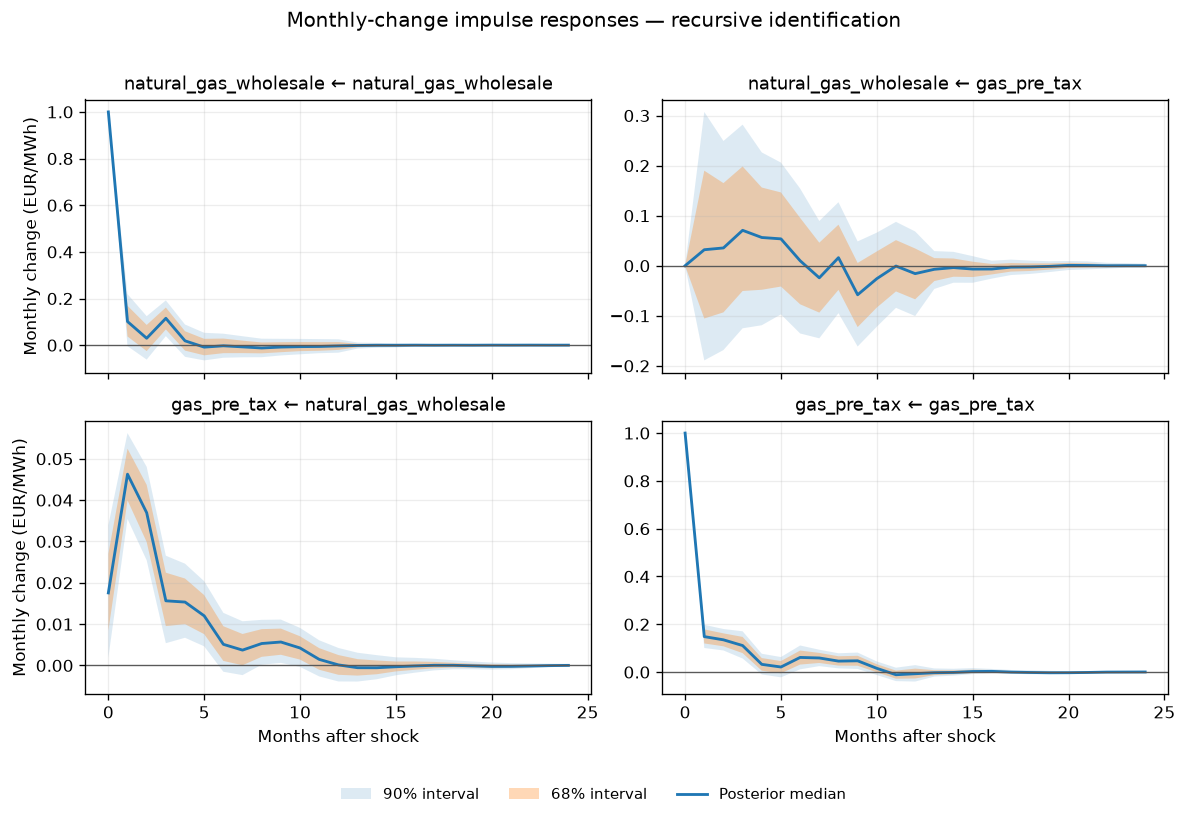

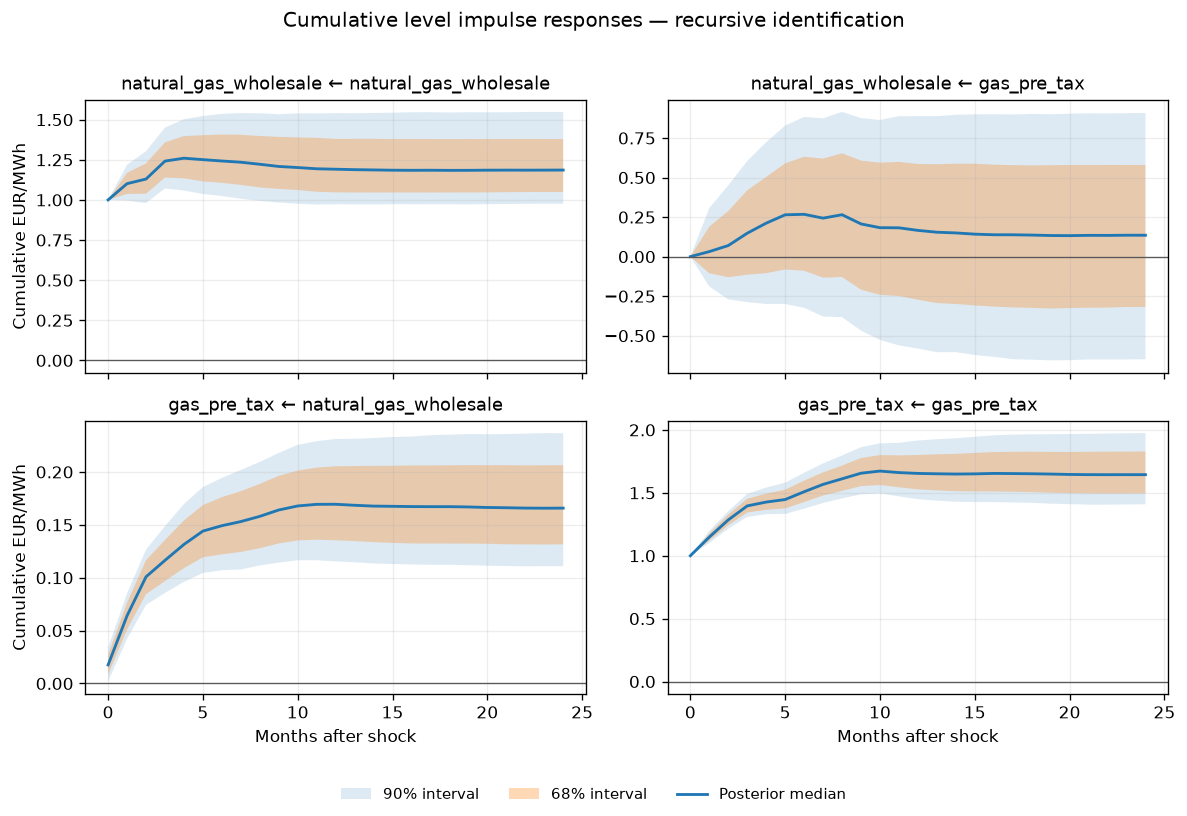

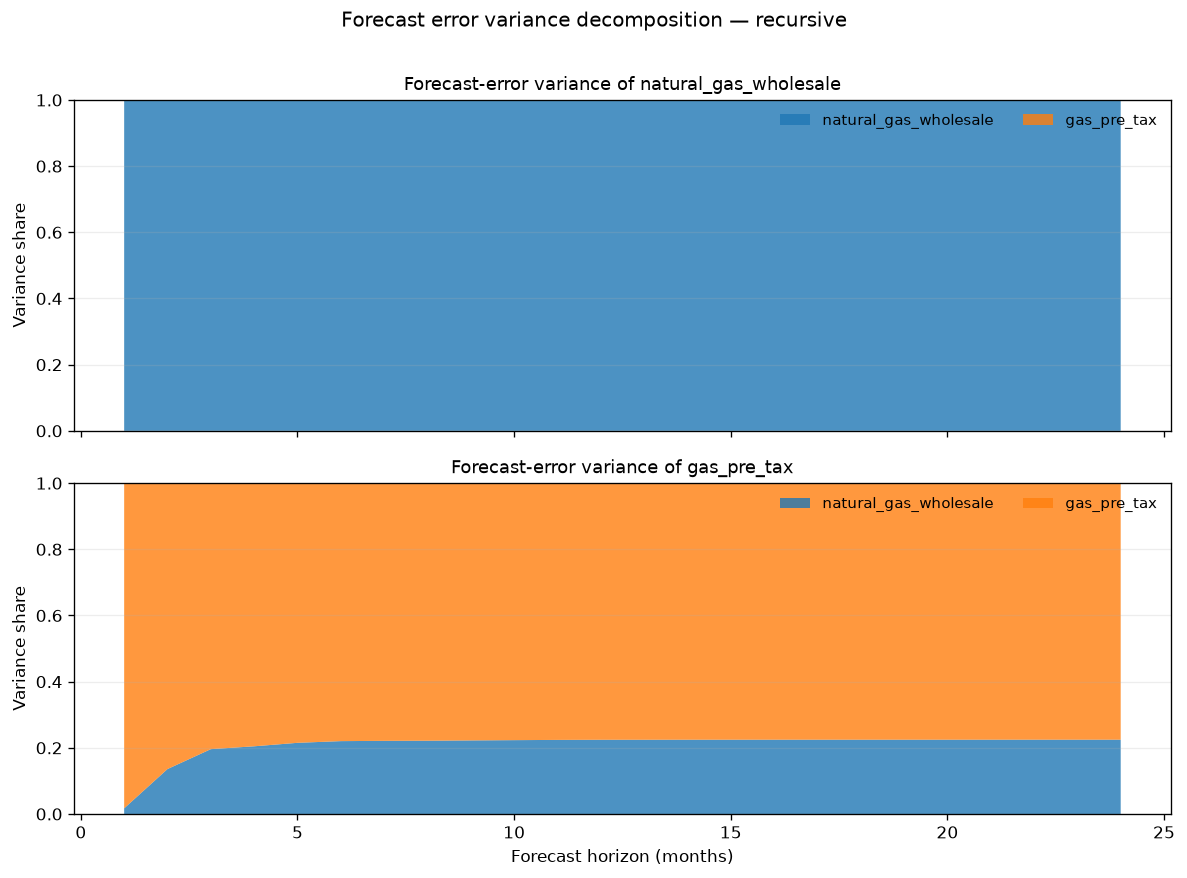

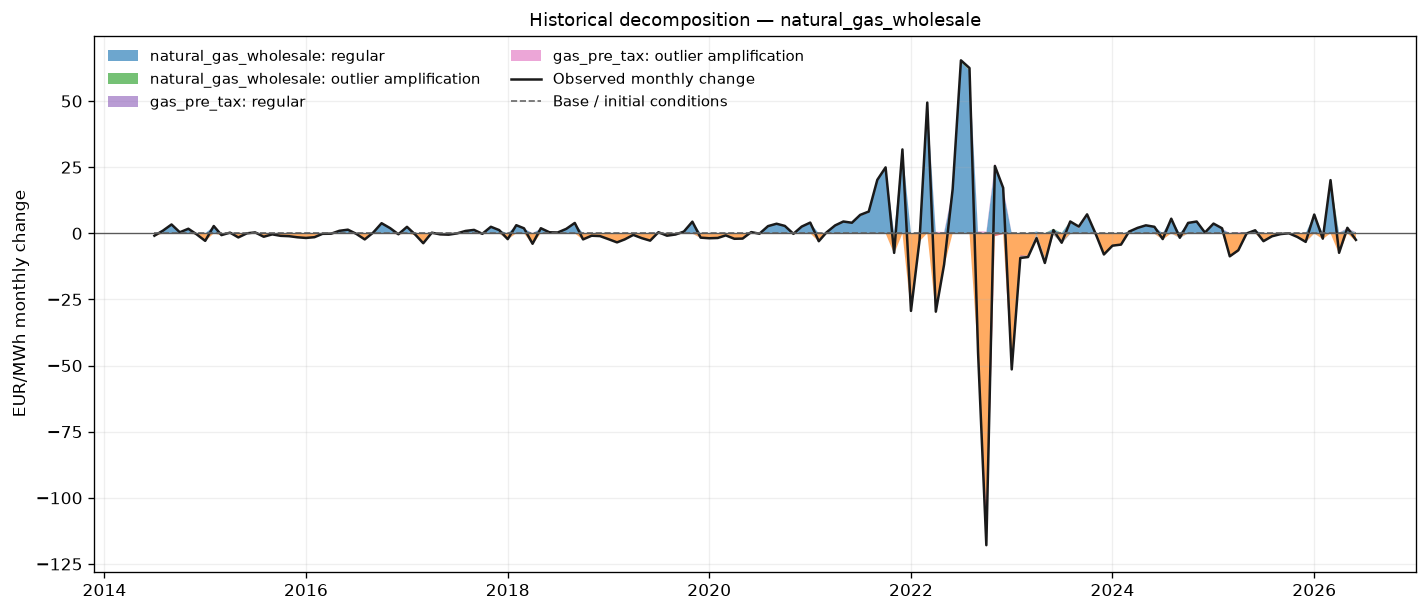

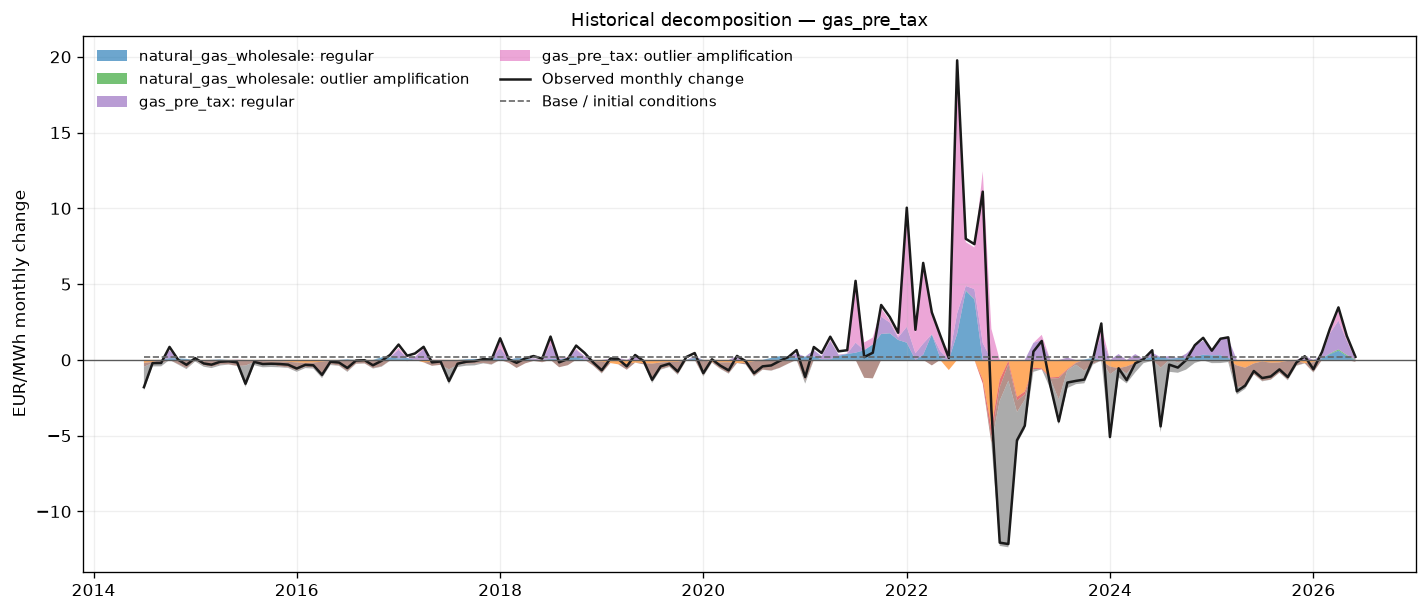


Sign-restricted identification
Accepted posterior-draw share: 100.00%
Mean rotation attempts per accepted draw: 3.15
HD maximum reconstruction error: 1.28 × 10⁻¹³


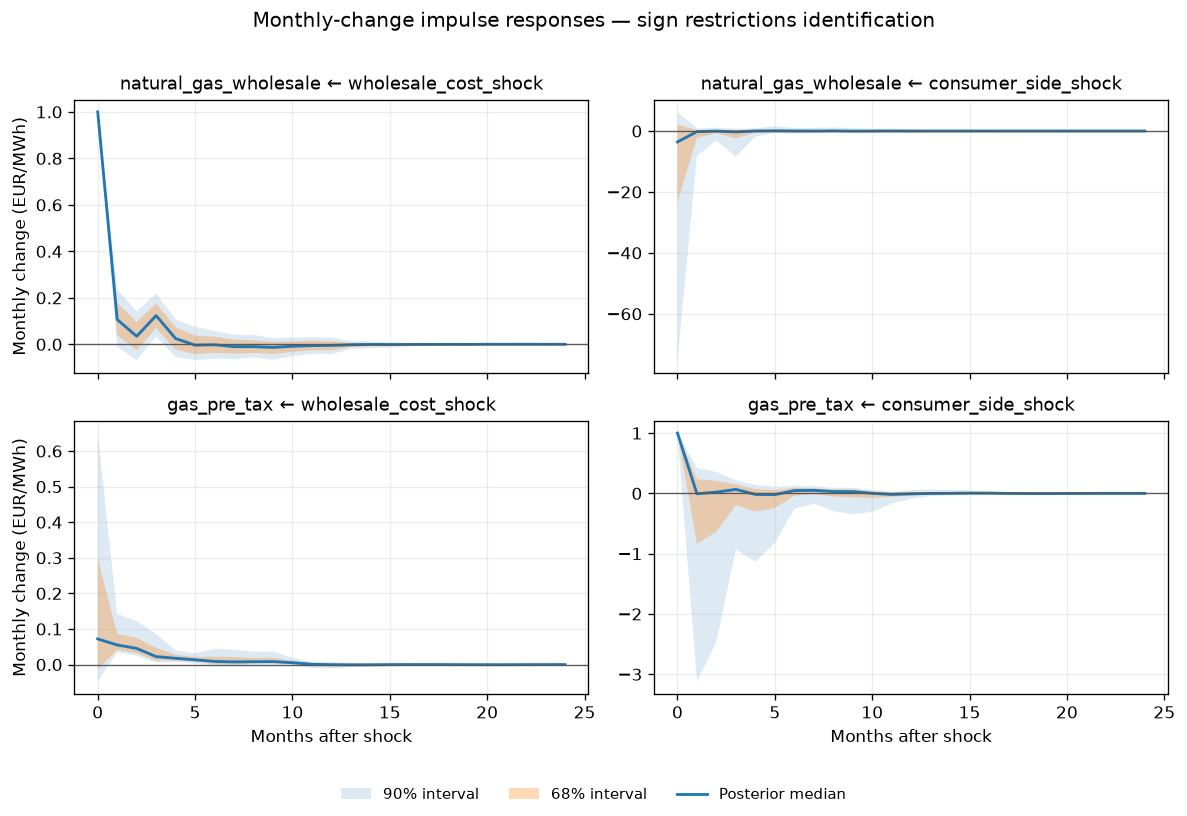

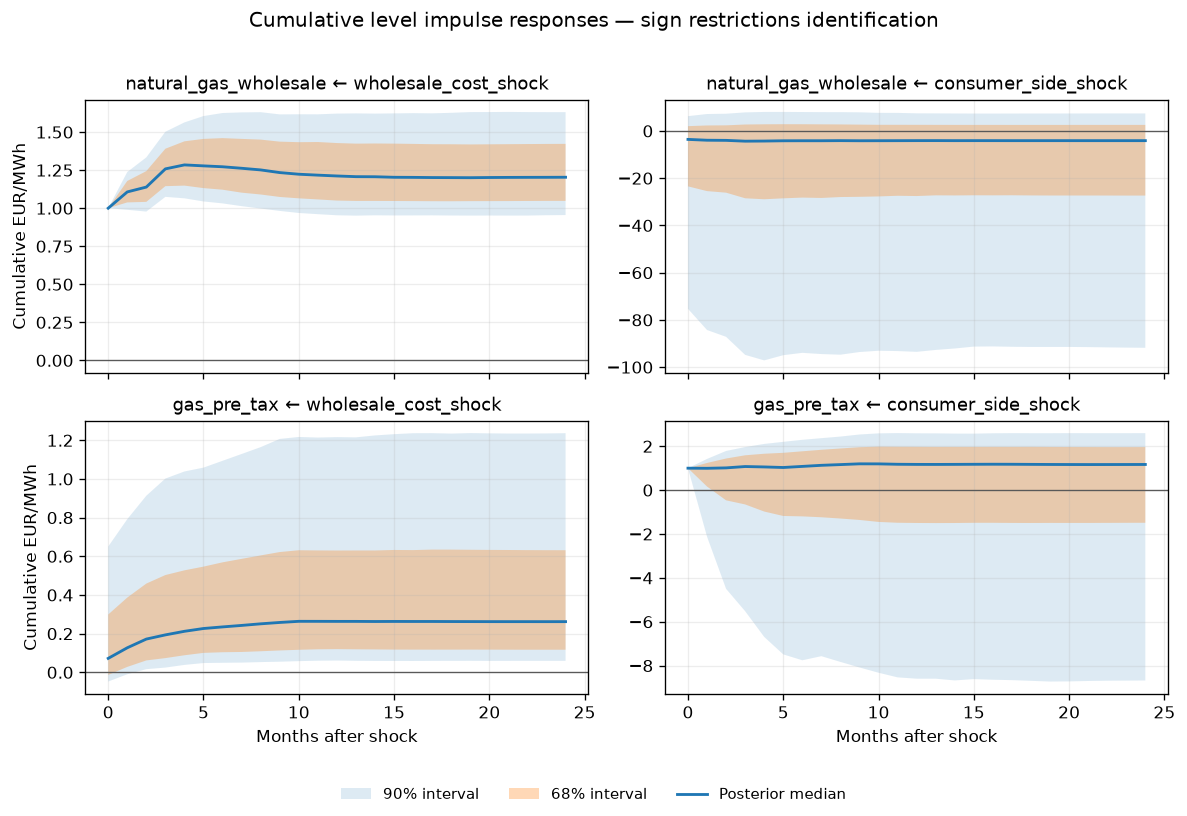

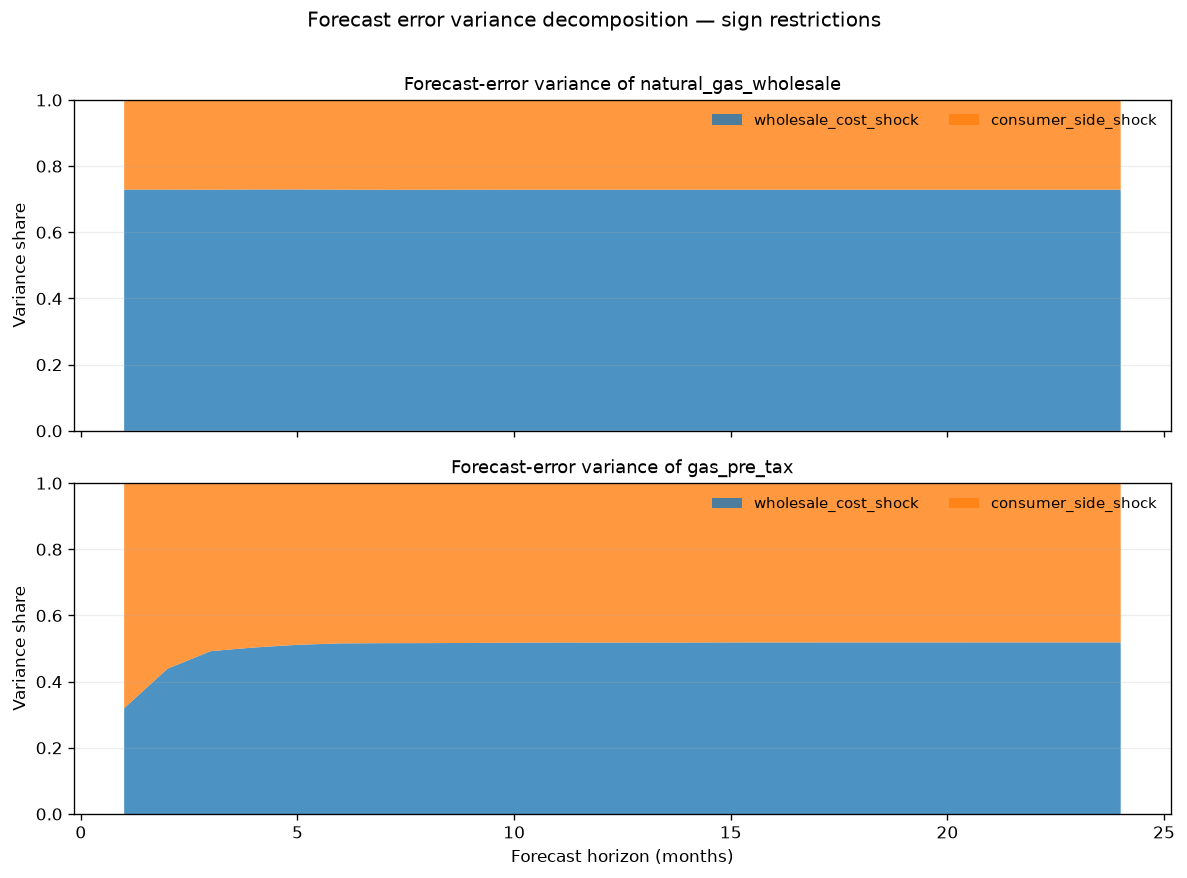

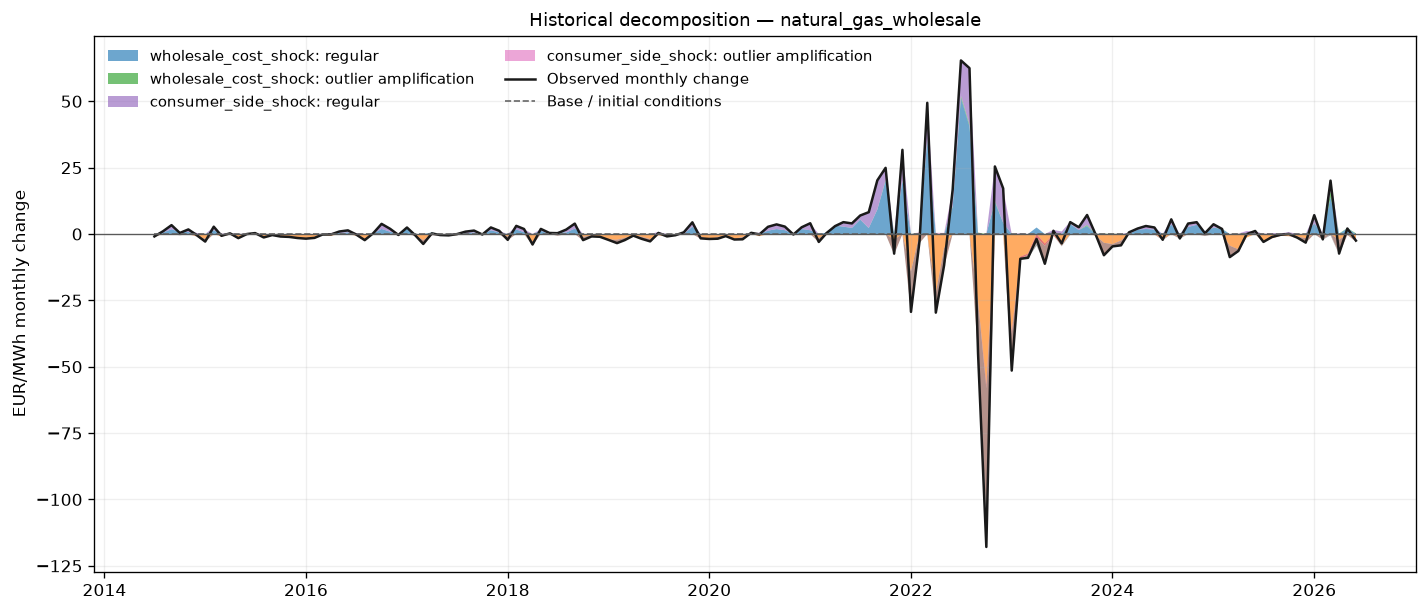

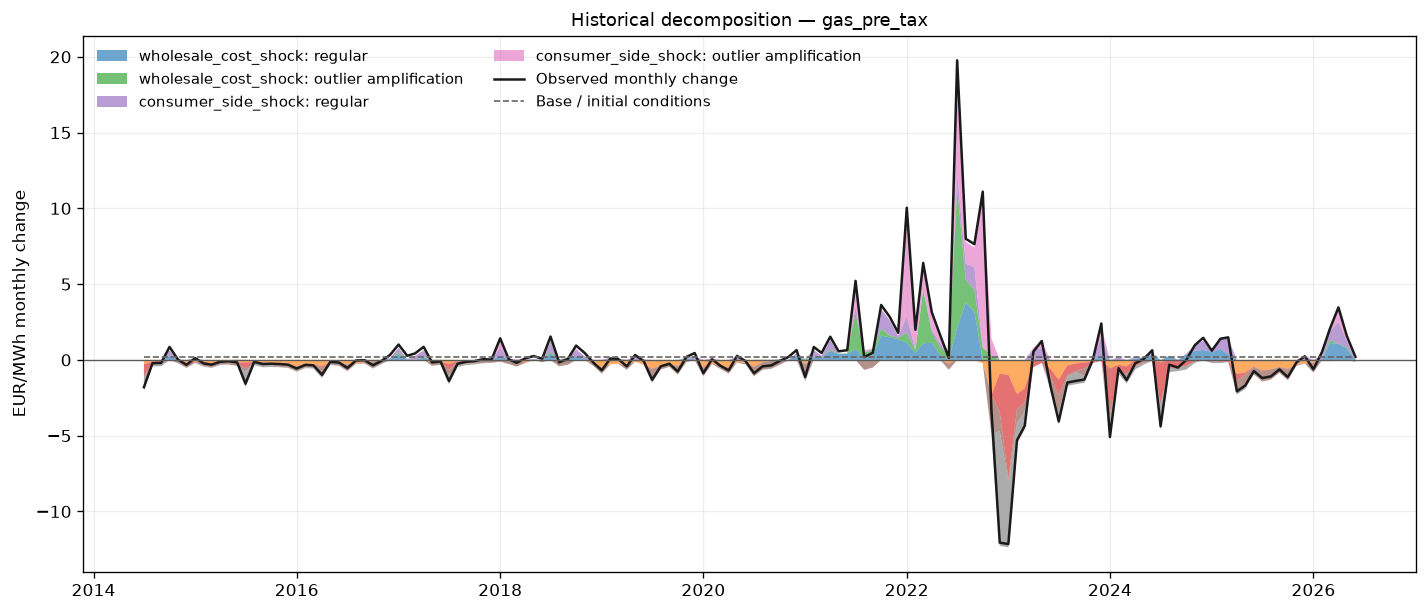

In [ ]:
# Structural restrictions. Dictionary insertion order fixes shock-column order.
GAS_SIGN_RESTRICTIONS = {
    "wholesale_cost_shock": {
        "natural_gas_wholesale": {0: +1},
    },
    "consumer_side_shock": {
        "gas_pre_tax": {0: +1},
    },
}

# Retail pass-through may be delayed, so impose a positive cumulative response
# by month 3 rather than requiring every monthly response to be positive.
GAS_CUMULATIVE_RESTRICTIONS = {
    "wholesale_cost_shock": {
        "gas_pre_tax": {3: +1},
    }
}

STRUCTURAL_REFERENCE_DATE = prep["balanced_end"]
STRUCTURAL_HORIZON = 12

# ------------------------------------------------------------------
# Recursive identification
# ------------------------------------------------------------------
irf_recursive = gas_impulse_responses(
    result,
    identification="recursive",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    horizon=STRUCTURAL_HORIZON,
    shock_unit="level",
    shock_size=1.0,
    include_outlier_scale=False,
)

fevd_recursive = gas_fevd(
    result,
    identification="recursive",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    horizon=STRUCTURAL_HORIZON,
    include_outlier_scale=False,
)

hd_recursive = gas_historical_decomposition(
    result,
    identification="recursive",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    split_outlier_amplification=True,
)

print("Recursive identification")
print(f"Reference date: {pd.Timestamp(STRUCTURAL_REFERENCE_DATE).date()}")
print(f"HD maximum reconstruction error: {format_number(hd_recursive['max_reconstruction_error'])}")

plot_gas_irf(irf_recursive, cumulative=False)
plot_gas_irf(irf_recursive, cumulative=True)
plot_gas_fevd(fevd_recursive)

for response in VARIABLES:
    plot_gas_historical_decomposition(hd_recursive, response=response, last_obs=144)
plt.show()

# ------------------------------------------------------------------
# Sign-restricted identification
# ------------------------------------------------------------------
irf_sign = gas_impulse_responses(
    result,
    identification="sign",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    sign_restrictions=GAS_SIGN_RESTRICTIONS,
    cumulative_restrictions=GAS_CUMULATIVE_RESTRICTIONS,
    horizon=STRUCTURAL_HORIZON,
    shock_unit="level",
    shock_size=1.0,
    normalization_variables={
        "wholesale_cost_shock": "natural_gas_wholesale",
        "consumer_side_shock": "gas_pre_tax",
    },
    include_outlier_scale=False,
    max_tries=10_000,
    seed=SEED,
)

fevd_sign = gas_fevd(
    result,
    identification="sign",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    sign_restrictions=GAS_SIGN_RESTRICTIONS,
    cumulative_restrictions=GAS_CUMULATIVE_RESTRICTIONS,
    horizon=STRUCTURAL_HORIZON,
    include_outlier_scale=False,
    max_tries=10_000,
    seed=SEED,
)

hd_sign = gas_historical_decomposition(
    result,
    identification="sign",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    sign_restrictions=GAS_SIGN_RESTRICTIONS,
    cumulative_restrictions=GAS_CUMULATIVE_RESTRICTIONS,
    split_outlier_amplification=True,
    max_tries=10_000,
    seed=SEED,
)

print("\nSign-restricted identification")
print(f"Accepted posterior-draw share: {irf_sign['acceptance_rate']:.2%}")
print(f"Mean rotation attempts per accepted draw: {irf_sign['mean_attempts_per_accepted_draw']:.2f}")
print(f"HD maximum reconstruction error: {format_number(hd_sign['max_reconstruction_error'])}")

plot_gas_irf(irf_sign, cumulative=False)
plot_gas_irf(irf_sign, cumulative=True)
plot_gas_fevd(fevd_sign)
for response in VARIABLES:
    plot_gas_historical_decomposition(hd_sign, response=response, last_obs=144)
plt.show()


## Structural analysis — reading the plots

**Units first.** Estimation is in absolute first differences (Δ EUR/MWh); the shock is a +1 EUR/MWh level impulse. Responses are *not* standard deviations: the monthly-change IRF is the effect on the change, and the cumulative IRF sums those changes and is therefore the effect on the **level**. IRF/FEVD are indexed by months *after the shock*, not calendar time — `reference_date` only fixes the volatility state Σₜ at end-of-sample.

### Recursive identification (Cholesky, wholesale-first)

- **Monthly IRF.** A +1 EUR/MWh wholesale shock lifts pre-tax by ~0.02 on impact (the contemporaneous loading a₂₁), peaks ~0.045 at 1–2 months, then decays to zero — the decay is governed by the VAR coefficients. The reverse response (wholesale to a pre-tax shock) is zero on impact by construction and straddles zero after: no reverse causality.
- **Cumulative IRF.** Long-run pass-through ~0.17 EUR/MWh on the level — about 17% of a wholesale move settles into the retail pre-tax price. This is the economically meaningful number.
- **FEVD.** Wholesale ~100% own; pre-tax ~78% own / ~22% wholesale. Coherent, not disappointing: wholesale being ~6× more volatile affects IRF magnitudes, not FEVD shares. Pre-tax's own dynamics dominate its variance, and 22% lines up with the 17% pass-through.
- **HD.** The 2021–2023 pre-tax spikes are at least half attributed to its own outlier channel — abnormal, not regular volatility — while wholesale is essentially all "regular". Exactly the SV-vs-outlier split expected.

### Sign-restricted identification

- **Shock names.** `wholesale_cost_shock` = restricted to push wholesale ≥ 0 on impact (upstream cost). `consumer_side_shock` = pushes pre-tax ≥ 0 without being the wholesale shock (retail-internal: margins, network, regulation).
- **Monthly IRF.** Wholesale cost shock raises wholesale by ~1 on impact (efficient market) and pre-tax by < 0.1.
- **Cumulative IRF.** Pass-through ~0.27 EUR/MWh on the level — same sign and order of magnitude as the recursive 0.17. The robust result.
- **FEVD.** Very different (wholesale ~27% consumer_side; pre-tax ~52% wholesale_cost) — but treat as an identification artefact, not an alternative truth.
- **HD.** Hard to read; under-identified rotations make the re-attribution unreliable.

### Caveat — why the sign FEVD/HD aren't trustworthy

The restriction set never constrains `consumer_side → wholesale`. Left free, the accepted rotations drive it to ~−60 EUR/MWh monthly (−90 cumulative), which is economic nonsense. Since the FEVD/HD use the whole rotation, the 27% assigned to consumer_side flows through that unconstrained cell — so the sign FEVD/HD should not be cited as economic facts until it's bounded (impose `consumer_side → wholesale` ≥ 0 on impact). The recursive scheme has no such hole because the ordering fixes that cell to zero.

### Bottom line

Pass-through is robust (positive, ~0.17 recursive to ~0.27 sign, on the level). The schemes disagree only on the reverse channel, which recursive zeroes by assumption and sign fails to pin down. Trust the recursive FEVD/HD; hold the sign FEVD/HD in reserve until the missing restriction is added.
```

## 9. Diagnosis

### 9.1 Stationarity of transformed data

In [14]:
stationarity_table = stationarity_tests(prep["balanced"])
display(style_numeric_table(stationarity_table, caption="Stationarity diagnostics"))

,ADF statistic,ADF p-value,ADF lags,KPSS statistic,KPSS p-value,KPSS lags,observations
variable,,,,,,,
natural_gas_wholesale,-4.71,8.17 × 10⁻⁵,15.00,0.04,0.10,25.00,259.00
gas_pre_tax,-3.69,4.25 × 10⁻³,16.00,0.05,0.10,8.00,258.00


ADF/KPSS diagnostics concern the transformed observed series. They are distinct from VAR stability, which concerns the eigenvalues of the companion matrix for each posterior coefficient draw.

### 9.2 MCMC effective sample size and autocorrelation

,posterior_mean,posterior_sd,ESS,MCSE_mean,MCSE_over_sd
phi[gas_pre_tax],0.02,7.30 × 10⁻³,97.03,7.41 × 10⁻⁴,0.10
phi[natural_gas_wholesale],0.19,0.06,135.78,5.13 × 10⁻³,0.09
log likelihood,-786.40,12.28,182.09,0.91,0.07
p_outlier[gas_pre_tax],0.09,0.02,226.73,1.28 × 10⁻³,0.07
p_outlier[natural_gas_wholesale],0.01,6.32 × 10⁻³,481.96,2.88 × 10⁻⁴,0.05
own L1[natural_gas_wholesale],0.10,0.07,646.95,2.69 × 10⁻³,0.04
"A[gas_pre_tax,natural_gas_wholesale]",-0.02,9.58 × 10⁻³,882.88,3.22 × 10⁻⁴,0.03
own L1[gas_pre_tax],0.15,0.03,895.31,1.00 × 10⁻³,0.03
spectral radius,0.80,0.02,2236.11,4.39 × 10⁻⁴,0.02


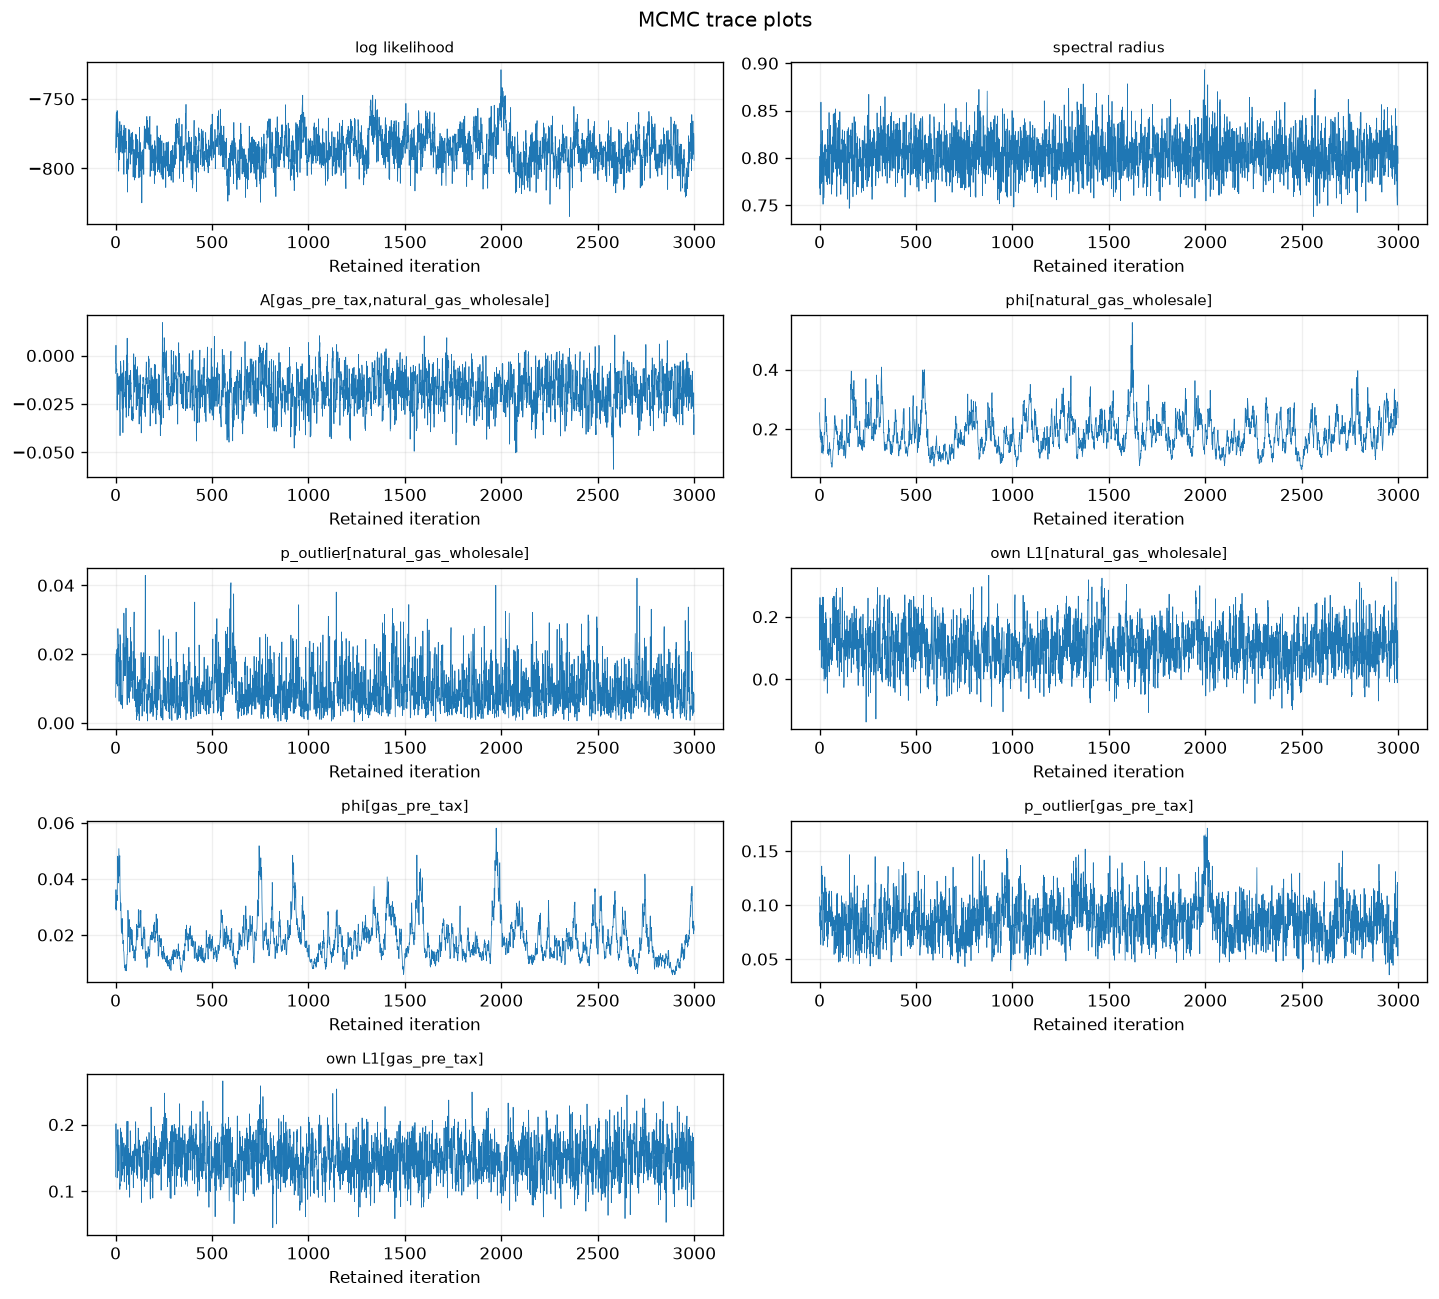

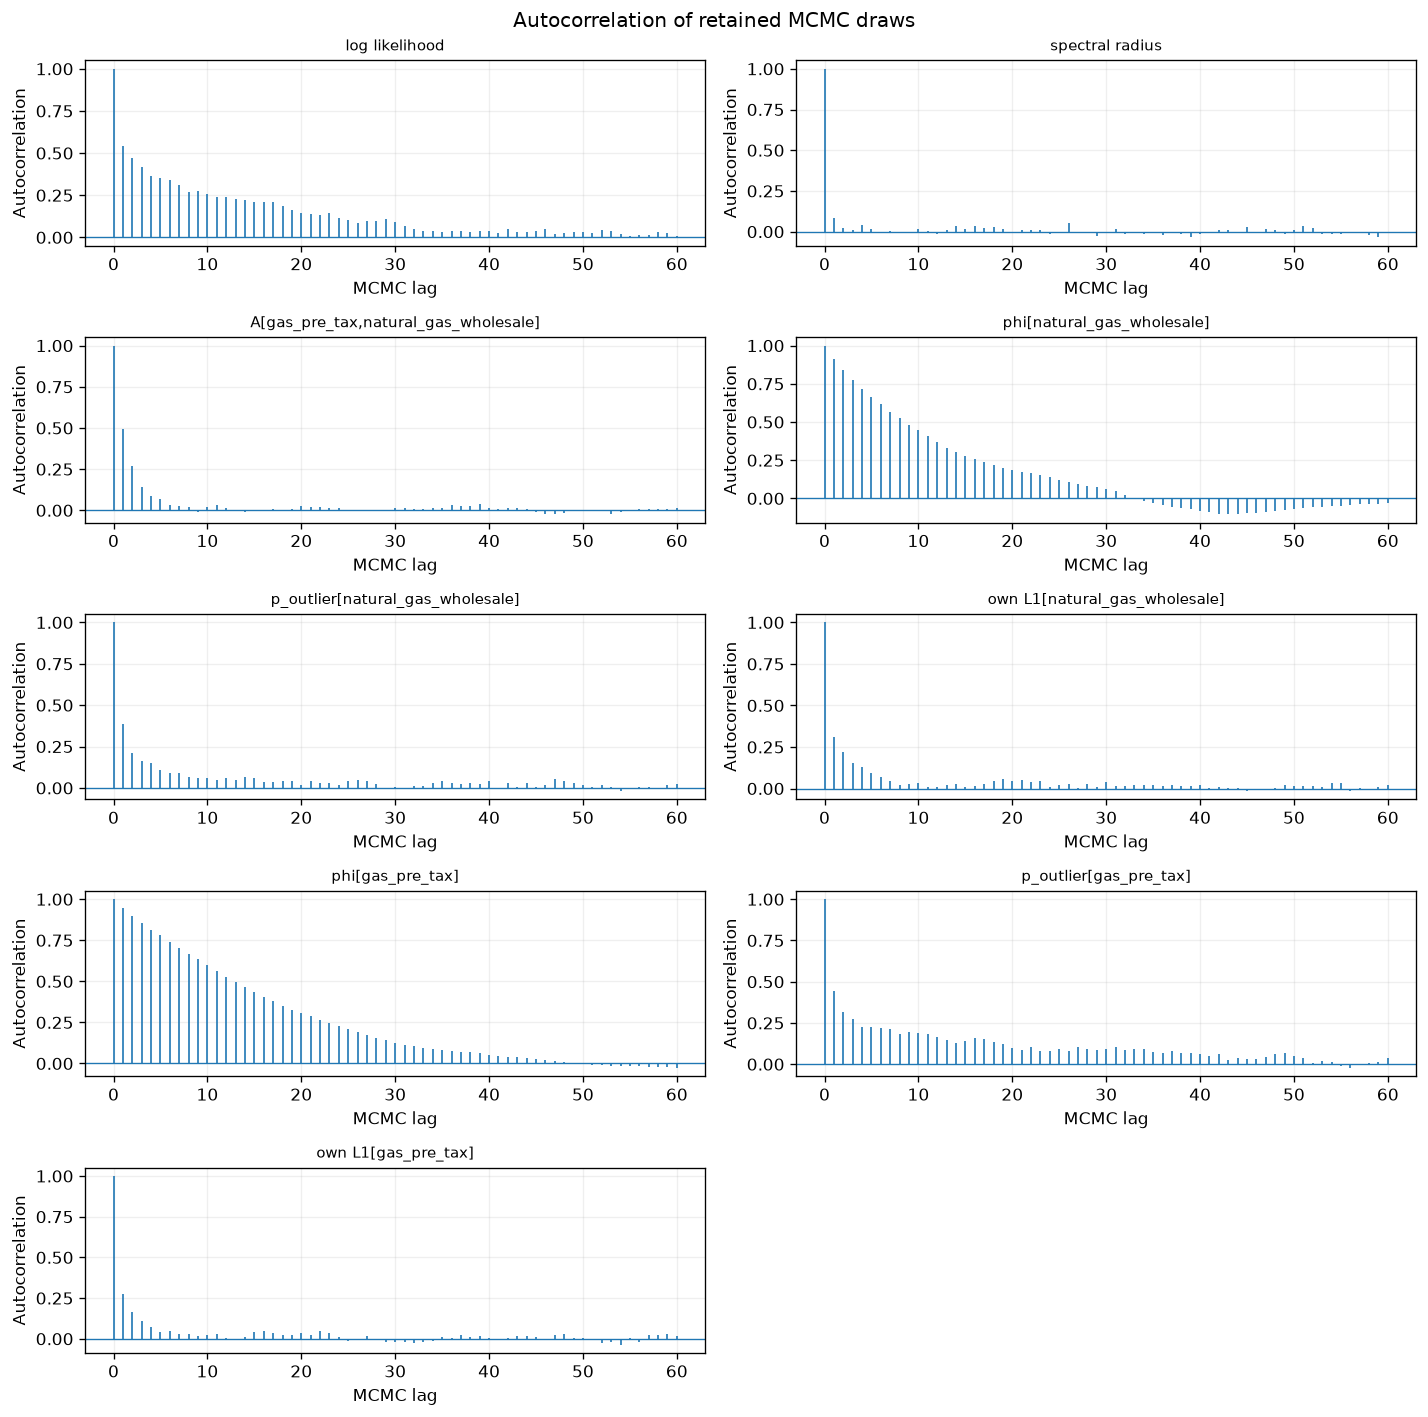

In [15]:
diagnostic_table = mcmc_diagnostics(result)
display(style_numeric_table(diagnostic_table.sort_values("ESS"), caption="MCMC diagnostics"))
plot_trace_grid(result)
plot_chain_acf_grid(result, nlags=60)
plt.show()

Phi's traces and autocorellation are not great. Suggest to move to ASCI sampling method.

### 9.3 Stability

,value
retained_draws,3000.00
median_spectral_radius,0.80
q95_spectral_radius,0.84
maximum_spectral_radius,0.89
retained_unstable_share,0.00
B_total_proposals,6000.00
B_unstable_proposals,0.00
B_instability_rejection_rate,0.00


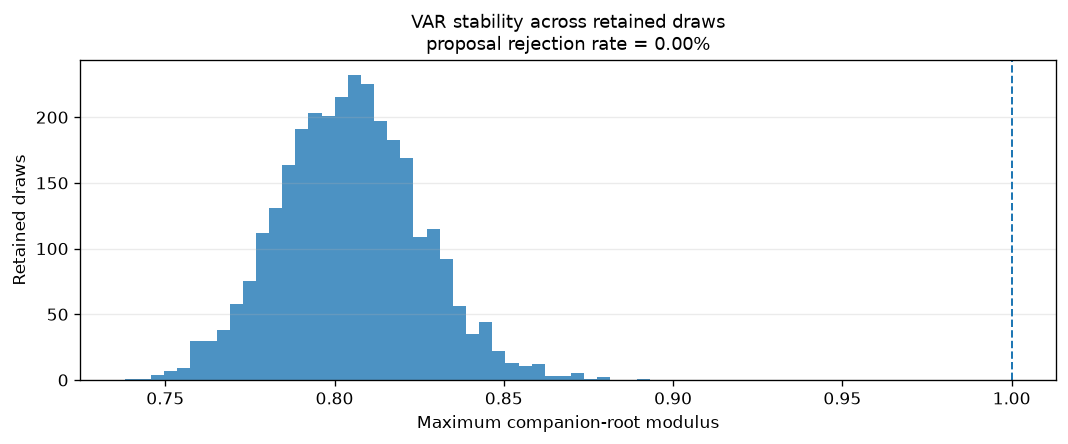

In [16]:
display(style_numeric_table(
    stability_diagnostics(result).to_frame("value"),
    caption="VAR stability diagnostics",
))
plot_spectral_radius(result)
plt.show()

### 9.5 Posterior predictive checks


Posterior predictive checks: natural_gas_wholesale


,observed,replicated_median,replicated_q05,replicated_q95
natural_gas_wholesale: mean,0.13,0.12,-1.50,1.89
natural_gas_wholesale: sd,11.79,10.35,7.32,25.38
natural_gas_wholesale: maximum_absolute,117.89,88.66,49.05,357.70


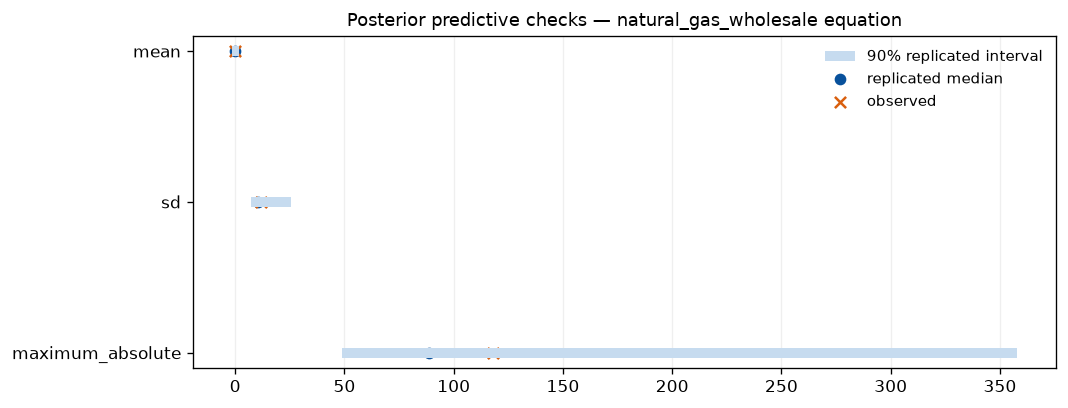


Posterior predictive checks: gas_pre_tax


,observed,replicated_median,replicated_q05,replicated_q95
gas_pre_tax: mean,0.18,0.20,-0.32,0.67
gas_pre_tax: sd,2.32,2.53,1.71,4.09
gas_pre_tax: maximum_absolute,19.77,23.09,12.52,42.69


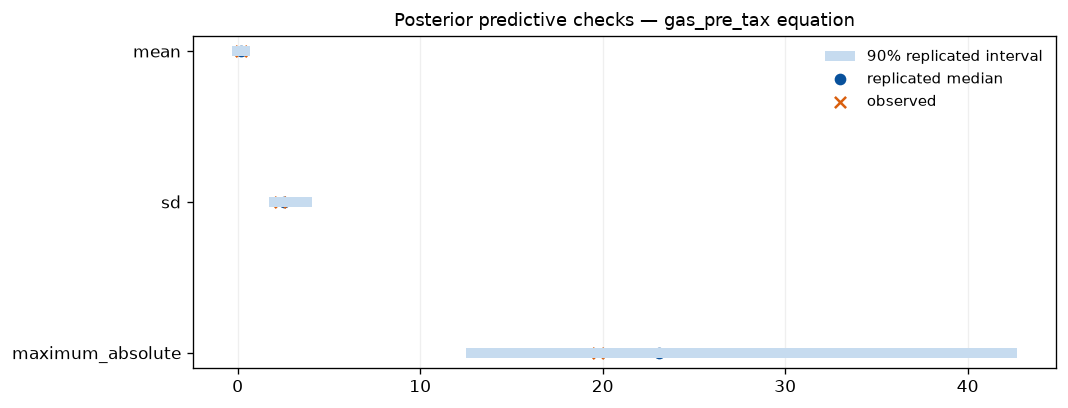

In [18]:
ppc_summary, ppc_draws = posterior_predictive_statistics(
    result,
    n_draws=min(300, result["n_draws"]),
    seed=2027,
)
for equation in VARIABLES:
    print(f"\nPosterior predictive checks: {equation}")
    equation_rows = ppc_summary.loc[
        [str(index).startswith(f"{equation}:") for index in ppc_summary.index]
    ]
    display(style_numeric_table(
        equation_rows,
        caption=f"Posterior predictive checks — {equation}",
    ))
    plot_posterior_predictive_check(ppc_summary, equation=equation)
    plt.show()

## 10. Sensitivity analysis (if time)

The baseline result should not be treated as final until the following specifications have been compared:

1. **Recursive ordering:** `[natural_gas_wholesale, gas_pre_tax]` versus the reverse ordering. This changes the structural shocks and their stochastic volatilities.
2. **Volatility prior:** alternative values for `phi_prior_mean` and `phi_prior_df`.
3. **Outlier prior:** alternative prior frequencies and concentrations around one outlier every four years.
4. **Future outliers:** predictive densities with `simulate_future_outliers=True` and with future scales fixed to one.
5. **Minnesota tightness:** a grid for `lambda1` and `lambda2`.
6. **Forecast scenario:** constant wholesale price, +10% permanent price, and externally supplied conditioning paths.

These are separate model runs. They should use the same vintage, same forecast origin, and common random seeds where possible.